# Project description: Survey

This project develops a human-machine framework to classify frost-related features in archaeological thin sections, addressing the challenges of subjective and time-consuming manual analysis. We combine five different Convolutional Neural Network (CNN) models with a blind survey of expert micromorphologists.

The code below is part of the expert survey analysis. This survey was a critical step in our research, designed to:

1. Validate our image dataset.

2. Quantify the variability and "label noise" inherent in expert classifications.

The survey focused on a subset of deliberately challenging images, asking experts to classify features related to frost action. The results from this survey serve as a benchmark for evaluating our automated classification models and provide key insights into human interpretive challenges.


This cell loads survey data from an Excel file on Google Drive and prepares it for visualization. It encodes categorical variables for level of expertise and experience with frost, bins respondents’ years in the field into ranges, and then builds two flows: expertise → years in field, and years in field → frost experience. These flows are combined into a Sankey diagram that shows how respondents’ expertise connects to their years of experience and their familiarity with frost features.

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# -------------------------------
# ENCODE CATEGORICAL VARIABLES
# -------------------------------

# Map categorical text to numeric codes
level_map = {
    'Beginner/Early Career': 1,
    'Intermediate': 2,
    'Advanced/Expert': 3
}

frost_map = {
    'Little to no experience': 1,
    'Some experience': 2,
    'Significant experience': 3
}

# Create coded columns
df["Level of expertise code"] = df["Level of expertise"].map(level_map)
df["Experience with frost code"] = df["Experience with frost"].map(frost_map)

# Map back to readable labels (for Plotly nodes)
level_map_text = {
    1: 'Beginner/Early Career',
    2: 'Intermediate',
    3: 'Advanced/Expert'
}

frost_map_text = {
    1: 'Little to no experience',
    2: 'Some experience',
    3: 'Significant experience'
}

df["Level of expertise text"] = df["Level of expertise code"].map(level_map_text)
df["Experience with frost text"] = df["Experience with frost code"].map(frost_map_text)

# -------------------------------
# BIN YEARS IN FIELD
# -------------------------------

bins = [0, 5, 10, 20, 100]
labels = ['1-5', '6-10', '11-20', '>20']

df['Years Bin'] = pd.cut(df['Years in field'], bins=bins, labels=labels, right=True)

# -------------------------------
# BUILD NEW SANKEY FLOWS
# -------------------------------

# Flow 1: Level of expertise → Years Bin
flow1 = df.groupby(["Level of expertise text", "Years Bin"], observed=False).size().reset_index(name='count')

# Flow 2: Years Bin → Experience with frost
flow2 = df.groupby(["Years Bin", "Experience with frost text"], observed=False).size().reset_index(name='count')

# Create unique list of all nodes
labels_all = pd.concat([
    flow1["Level of expertise text"],
    flow1["Years Bin"],
    flow2["Experience with frost text"]
]).dropna().unique().tolist()

# Create mapping of label names to indices
label_indices = {label: i for i, label in enumerate(labels_all)}

# -------------------------------
# DEFINE COLORS FOR EACH NODE
# -------------------------------

# Define shades for each group
expertise_colors = {
    'Beginner/Early Career': 'rgba(173, 216, 230, 0.9)',   # light blue
    'Intermediate': 'rgba(70, 130, 180, 0.9)',             # medium blue
    'Advanced/Expert': 'rgba(0, 51, 102, 0.9)'             # dark blue
}

years_colors = {
    '1-5': 'rgba(200, 230, 201, 0.9)',   # light green
    '6-10': 'rgba(120, 200, 120, 0.9)',  # medium green
    '11-20': 'rgba(56, 142, 60, 0.9)',   # darker green
    '>20': 'rgba(27, 94, 32, 0.9)'       # darkest green
}

frost_colors = {
    'Little to no experience': 'rgba(255, 204, 203, 0.9)',  # light red/pink
    'Some experience': 'rgba(239, 83, 80, 0.9)',            # medium red
    'Significant experience': 'rgba(183, 28, 28, 0.9)'      # dark red
}

# Assign colors to nodes based on their group
node_colors = []
for label in labels_all:
    if label in expertise_colors:
        node_colors.append(expertise_colors[label])
    elif label in years_colors:
        node_colors.append(years_colors[label])
    elif label in frost_colors:
        node_colors.append(frost_colors[label])
    else:
        node_colors.append('lightgray')

# Make labels bold by wrapping in HTML tags
labels_bold = [f"<b>{label}</b>" for label in labels_all]

# Prepare source, target, value lists
source = []
target = []
value = []

# Flow 1 connections
for _, row in flow1.iterrows():
    src = label_indices[row["Level of expertise text"]]
    tgt = label_indices[row["Years Bin"]]
    source.append(src)
    target.append(tgt)
    value.append(row["count"])

# Flow 2 connections
for _, row in flow2.iterrows():
    src = label_indices[row["Years Bin"]]
    tgt = label_indices[row["Experience with frost text"]]
    source.append(src)
    target.append(tgt)
    value.append(row["count"])

# -------------------------------
# PLOT SANKEY DIAGRAM
# -------------------------------

fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=labels_bold,  # Use bold labels
        color=node_colors
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    ),
    textfont=dict(size=18)
)])

fig.update_layout(
    title_text="Responders' Profiles (Expertise → Years → Frost Experience)",
    font_size=18
)
fig.show()




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In this cell, we plot the distributions of the answers for both vis_img and class_img.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


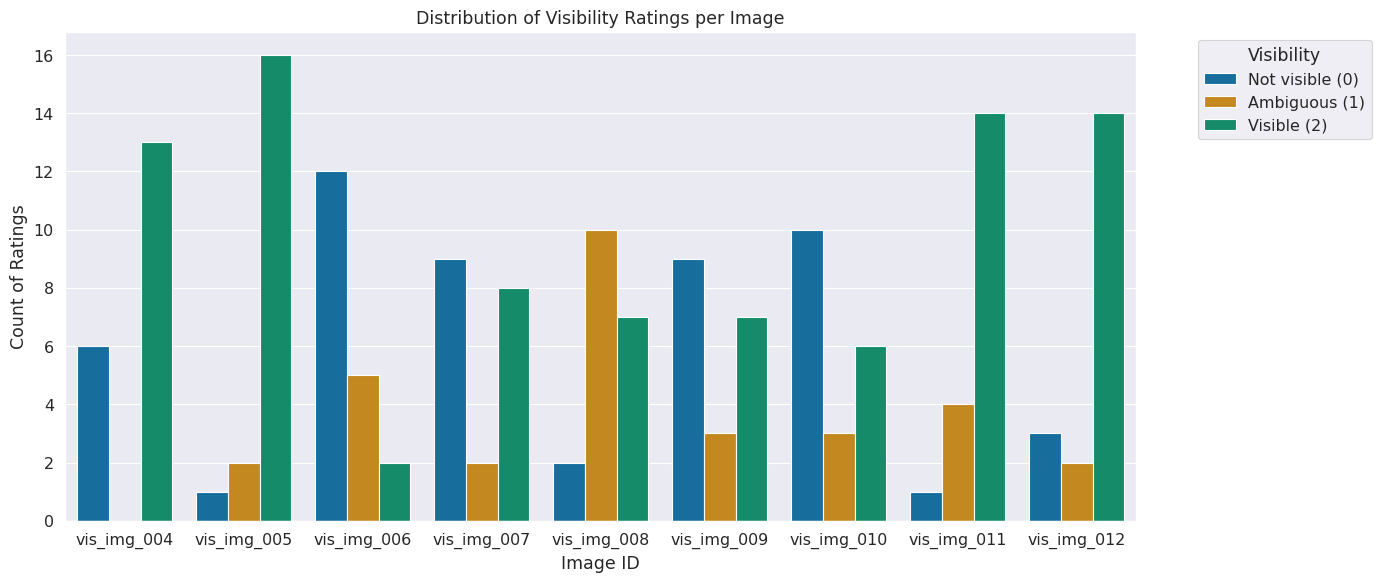

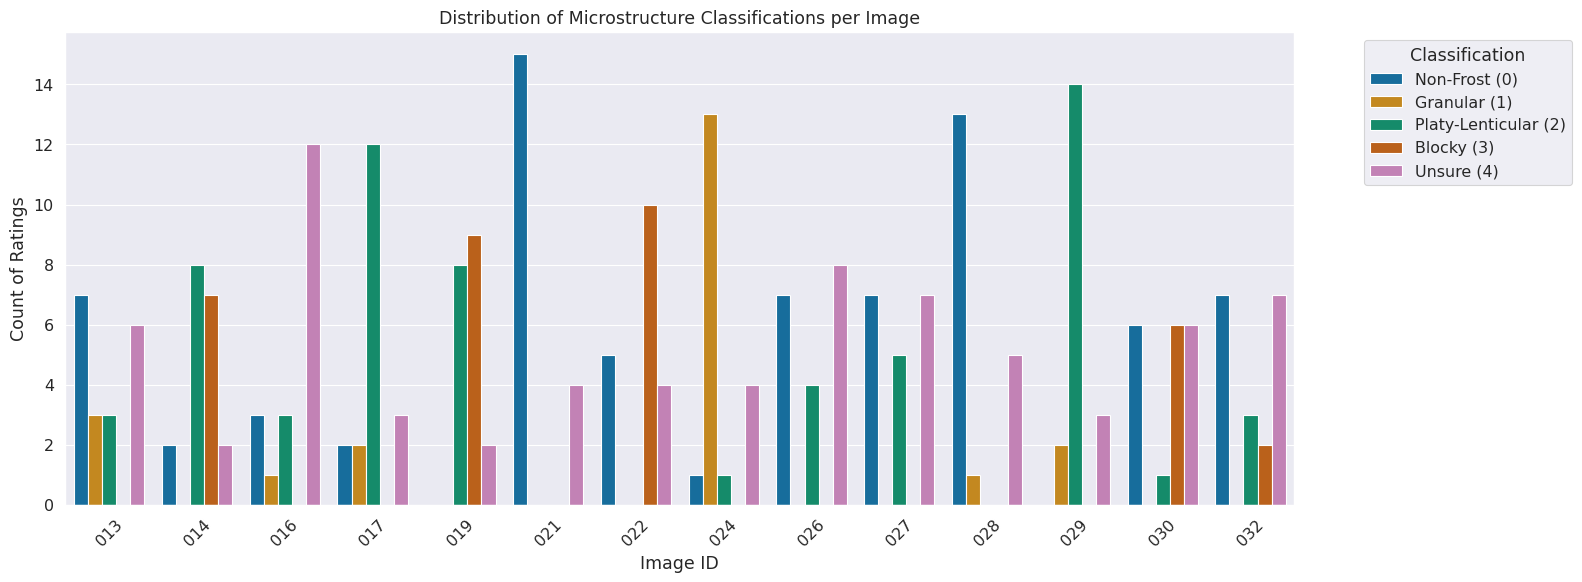

In [25]:
import numpy as np
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Mount Google Drive
drive.mount('/content/drive')

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# Remove ground truth row (ID = 20)
df_raters = df[df["ID"] != 20]

# Define column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# Output directory (adjust if needed)
output_dir = "/content/drive/My Drive"
os.makedirs(output_dir, exist_ok=True)

sns.set_style("darkgrid")

# -------- VIS_IMG PER-IMAGE DISTRIBUTION --------
df_vis = df_raters[vis_cols]

df_long_vis = df_vis.melt(var_name='Image', value_name='Visibility')
plt.figure(figsize=(14, 6))
sns.countplot(
    x='Image',
    hue='Visibility',
    data=df_long_vis,
    palette="colorblind"
)
plt.title("Distribution of Visibility Ratings per Image")
plt.xlabel("Image ID")
plt.ylabel("Count of Ratings")
plt.legend(
    title="Visibility",
    labels=["Not visible (0)", "Ambiguous (1)", "Visible (2)"],
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "countplot_visibility.tif"), dpi=400, bbox_inches='tight')
plt.show()

# -------- CLASS_IMG PER-IMAGE DISTRIBUTION (Improved) --------
df_class = df_raters[class_cols]

df_long_class = df_class.melt(var_name='Image', value_name='Classification')

# Shorten image labels to just numbers
df_long_class["Image"] = df_long_class["Image"].str.replace("class_img_", "")

plt.figure(figsize=(16, 6))  # wider figure
sns.countplot(
    x='Image',
    hue='Classification',
    data=df_long_class,
    palette="colorblind"
)

plt.title("Distribution of Microstructure Classifications per Image")
plt.xlabel("Image ID")
plt.ylabel("Count of Ratings")

# Rotate x-axis labels for readability
plt.xticks(rotation=45)

plt.legend(
    title="Classification",
    labels=["Non-Frost (0)", "Granular (1)", "Platy-Lenticular (2)", "Blocky (3)", "Unsure (4)"],
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "countplot_classification_improved.tif"), dpi=400, bbox_inches='tight')
plt.show()

In this cell, we import the dataframe and compute Fleiss Kappa for the both vis_img and class_img across participants. We exclude the ID = 20 which corresponds to the ground truth. We compute Fleiss Kappa because we want to check the inter-rater agreement.

In [26]:
import numpy as np
import pandas as pd
from statsmodels.stats.inter_rater import fleiss_kappa
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# Remove ground truth row (ID = 20)
df_raters = df[df["ID"] != 20]

# ---------------------------
# Prepare VIS_IMG data
# ---------------------------
vis_cols = [c for c in df_raters.columns if c.startswith("vis_img")]
vis_data = df_raters[vis_cols]

# Number of categories for vis_img responses (0=No, 1=Unsure, 2=Yes)
n_cat_vis = 3

# Count how many raters chose each category per image
vis_matrix = []
for col in vis_data.columns:
    counts = np.zeros(n_cat_vis, dtype=int)
    for c in range(n_cat_vis):
        counts[c] = (vis_data[col] == c).sum()
    vis_matrix.append(counts)
vis_matrix = np.array(vis_matrix)

# Fleiss' Kappa for vis_img
kappa_vis = fleiss_kappa(vis_matrix)

# ---------------------------
# Prepare CLASS_IMG data
# ---------------------------
class_cols = [c for c in df_raters.columns if c.startswith("class_img")]
class_data = df_raters[class_cols]

# Number of categories for class_img responses (0=Non-frost, 1=Granular, 2=Platy, 3=Blocky, 4=Unsure)
n_cat_class = 5

class_matrix = []
for col in class_data.columns:
    counts = np.zeros(n_cat_class, dtype=int)
    for c in range(n_cat_class):
        counts[c] = (class_data[col] == c).sum()
    class_matrix.append(counts)
class_matrix = np.array(class_matrix)

# Fleiss' Kappa for class_img
kappa_class = fleiss_kappa(class_matrix)

print("Fleiss' Kappa (vis_img):", kappa_vis)
print("Fleiss' Kappa (class_img):", kappa_class)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fleiss' Kappa (vis_img): 0.14987152273489
Fleiss' Kappa (class_img): 0.20776006316711046


This code computes the Cohen's Kappa vs. Ground truth to check the degree of agreement per rater vs. ground truth.

This code measures how much each rater agrees with the ground truth (ID 20) using Cohen’s Kappa for both visual and classification ratings. It then compares those agreement scores across raters with different levels of frost experience, and visualizes the results with a boxplot + stripplot.

Mounted at /content/drive
    Rater_ID  Cohen_Kappa_vis  Cohen_Kappa_class
0          1              0.0           0.416667
1          2              0.0           0.358779
2          3              0.0           0.416667
3          4              0.0           0.358779
4          5              0.0           0.542484
5          6              0.0           0.490909
6          7              0.0           0.125000
7          8              0.0           0.400000
8          9              0.0           0.120000
9         10              0.0           0.280000
10        11              0.0           0.621622
11        12              0.0           0.527027
12        13              0.0           0.019108
13        14              0.0           0.176471
14        15              0.0           0.454545
15        16              0.0          -0.022472
16        17              0.0           0.371795
17        18              0.0           0.045455
18        19              0.0           0.4

/tmp/ipykernel_870/572532987.py:67: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




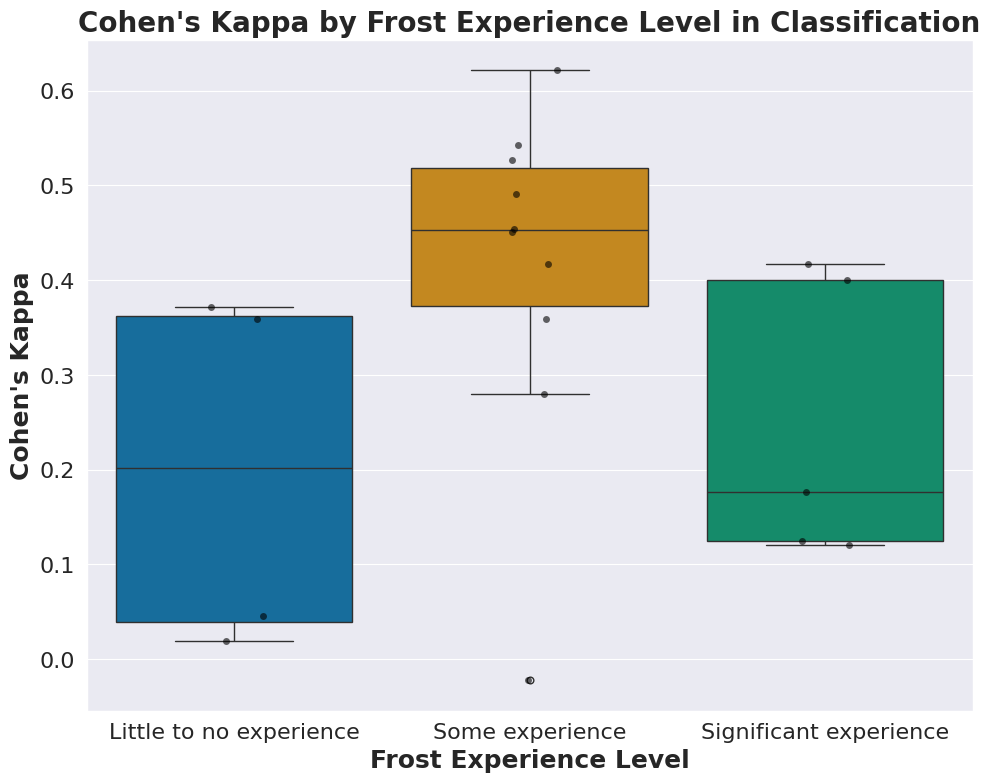

In [27]:
from sklearn.metrics import cohen_kappa_score
import pandas as pd
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Get column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# Initialize results storage
results = []

# Loop through raters
for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # Ensure arrays are integers
    y_true_vis = df_gt.loc[0, vis_cols].to_numpy().astype(int)
    y_pred_vis = row[vis_cols].to_numpy().astype(int)

    y_true_class = df_gt.loc[0, class_cols].to_numpy().astype(int)
    y_pred_class = row[class_cols].to_numpy().astype(int)

    # Compute Cohen's Kappa
    kappa_vis = cohen_kappa_score(y_pred_vis, y_true_vis)
    kappa_class = cohen_kappa_score(y_pred_class, y_true_class)

    results.append({
        "Rater_ID": rater_id,
        "Cohen_Kappa_vis": kappa_vis,
        "Cohen_Kappa_class": kappa_class
    })

# Convert to DataFrame
kappa_df = pd.DataFrame(results)

print(kappa_df)



#############################
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")

# Merge frost experience into kappa results
kappa_df = kappa_df.merge(
    df_raters[["ID", "Experience with frost"]],
    left_on="Rater_ID", right_on="ID", how="left"
)

# Create boxplot for class_img kappa vs frost experience
plt.figure(figsize=(10, 8))
ax = sns.boxplot(
    data=kappa_df,
    x="Experience with frost",
    y="Cohen_Kappa_class",
    palette="colorblind",
    order=["Little to no experience", "Some experience", "Significant experience"]  # custom order
)
sns.stripplot(
    data=kappa_df,
    x="Experience with frost",
    y="Cohen_Kappa_class",
    color="black", size=5, alpha=0.6,
    order=["Little to no experience", "Some experience", "Significant experience"]
)

# Add bold title with larger font
plt.title("Cohen's Kappa by Frost Experience Level in Classification",
          fontsize=20, fontweight='bold')

# Add bold axis labels with larger font
plt.ylabel("Cohen's Kappa", fontsize=18, fontweight='bold')
plt.xlabel("Frost Experience Level", fontsize=18, fontweight='bold')

# Increase tick label font sizes
ax.tick_params(axis='both', labelsize=16)

plt.tight_layout()
plt.savefig(os.path.join("/content/drive/My Drive", "kappa_class_boxplot_reordered.tif"),
            dpi=400, bbox_inches="tight")
plt.show()

Percentage of agreement per voter and per image:

Per rater → how much each rater agrees with the ground truth across all images.

Per image → how much all raters agree with the ground truth for that specific image.

In [28]:
import pandas as pd
import numpy as np

# Load data
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# Percent agreement per rater
# ----------------------------
per_rater_results = []

for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # VIS_IMG agreement
    vis_true = df_gt[vis_cols].to_numpy().astype(int).flatten()
    vis_pred = row[vis_cols].to_numpy().astype(int).flatten()
    vis_agreement = (vis_true == vis_pred).mean()

    # CLASS_IMG agreement
    class_true = df_gt[class_cols].to_numpy().astype(int).flatten()
    class_pred = row[class_cols].to_numpy().astype(int).flatten()
    class_agreement = (class_true == class_pred).mean()

    per_rater_results.append({
        "Rater_ID": rater_id,
        "Agreement_vis": vis_agreement,
        "Agreement_class": class_agreement
    })

per_rater_df = pd.DataFrame(per_rater_results)

# ----------------------------
# Percent agreement per image
# ----------------------------
per_image_results = []

# VIS_IMG
for col in vis_cols:
    true_vals = df_gt[col].iloc[0]
    matches = (df_raters[col] == true_vals).mean()
    per_image_results.append({
        "Image": col,
        "Type": "vis_img",
        "Agreement": matches
    })

# CLASS_IMG
for col in class_cols:
    true_vals = df_gt[col].iloc[0]
    matches = (df_raters[col] == true_vals).mean()
    per_image_results.append({
        "Image": col,
        "Type": "class_img",
        "Agreement": matches
    })

per_image_df = pd.DataFrame(per_image_results)

# ----------------------------
# Show results
# ----------------------------
print("Agreement per rater:")
print(per_rater_df)

print("\nAgreement per image:")
print(per_image_df)


Agreement per rater:
    Rater_ID  Agreement_vis  Agreement_class
0          1       0.555556         0.571429
1          2       0.444444         0.571429
2          3       0.444444         0.571429
3          4       0.444444         0.571429
4          5       0.888889         0.642857
5          6       0.444444         0.571429
6          7       0.111111         0.285714
7          8       0.777778         0.571429
8          9       0.555556         0.214286
9         10       0.555556         0.357143
10        11       0.777778         0.714286
11        12       0.555556         0.642857
12        13       0.555556         0.214286
13        14       0.111111         0.357143
14        15       0.888889         0.571429
15        16       0.555556         0.071429
16        17       0.222222         0.500000
17        18       0.555556         0.142857
18        19       0.222222         0.571429

Agreement per image:
            Image       Type  Agreement
0     vis_img_004

Percentage of agreement per voter and per image: (per rater & per image/ across raters & vs. Ground truth).

per_rater_df → agreement scores per rater, including:

Agreement vs ground truth

Agreement vs majority (across raters)

per_image_df → agreement scores per image, including:

Agreement vs ground truth

Agreement across raters

In [29]:
import pandas as pd
import numpy as np

# ----------------------------
# Load data
# ----------------------------
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# 1. RATER-LEVEL AGREEMENT
# ----------------------------
per_rater_results = []

for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # --- VIS_IMG ---
    vis_true = df_gt[vis_cols].to_numpy().astype(int).flatten()
    vis_pred = row[vis_cols].to_numpy().astype(int).flatten()

    # Agreement vs ground truth
    vis_vsGT = (vis_true == vis_pred).mean()

    # Agreement across raters (majority vote)
    vis_majority = df_raters[vis_cols].mode().iloc[0].to_numpy().astype(int).flatten()
    vis_vsMajority = (vis_pred == vis_majority).mean()

    # --- CLASS_IMG ---
    class_true = df_gt[class_cols].to_numpy().astype(int).flatten()
    class_pred = row[class_cols].to_numpy().astype(int).flatten()

    class_vsGT = (class_true == class_pred).mean()

    class_majority = df_raters[class_cols].mode().iloc[0].to_numpy().astype(int).flatten()
    class_vsMajority = (class_pred == class_majority).mean()

    per_rater_results.append({
        "Rater_ID": rater_id,
        "Agreement_vis_vsGT": vis_vsGT,
        "Agreement_vis_acrossRaters": vis_vsMajority,
        "Agreement_class_vsGT": class_vsGT,
        "Agreement_class_acrossRaters": class_vsMajority
    })

per_rater_df = pd.DataFrame(per_rater_results)

# ----------------------------
# 2. IMAGE-LEVEL AGREEMENT
# ----------------------------
per_image_results = []

# --- VIS_IMG ---
for col in vis_cols:
    true_val = df_gt[col].iloc[0]
    responses = df_raters[col].astype(int)

    # Agreement vs ground truth
    agreement_vsGT = (responses == true_val).mean()

    # Agreement across raters
    majority_val = responses.mode().iloc[0]
    agreement_across = (responses == majority_val).mean()

    per_image_results.append({
        "Image": col,
        "Type": "vis_img",
        "Agreement_vsGT": agreement_vsGT,
        "Agreement_acrossRaters": agreement_across
    })

# --- CLASS_IMG ---
for col in class_cols:
    true_val = df_gt[col].iloc[0]
    responses = df_raters[col].astype(int)

    agreement_vsGT = (responses == true_val).mean()
    majority_val = responses.mode().iloc[0]
    agreement_across = (responses == majority_val).mean()

    per_image_results.append({
        "Image": col,
        "Type": "class_img",
        "Agreement_vsGT": agreement_vsGT,
        "Agreement_acrossRaters": agreement_across
    })

per_image_df = pd.DataFrame(per_image_results)

# ----------------------------
# Show results
# ----------------------------
print("=== Agreement per Rater ===")
print(per_rater_df.round(3))   # rounded for readability

print("\n=== Agreement per Image ===")
print(per_image_df.round(3))


=== Agreement per Rater ===
    Rater_ID  Agreement_vis_vsGT  Agreement_vis_acrossRaters  \
0          1               0.556                       0.667   
1          2               0.444                       0.667   
2          3               0.444                       0.667   
3          4               0.444                       0.667   
4          5               0.889                       0.556   
5          6               0.444                       0.556   
6          7               0.111                       0.667   
7          8               0.778                       0.556   
8          9               0.556                       0.889   
9         10               0.556                       0.556   
10        11               0.778                       0.556   
11        12               0.556                       0.444   
12        13               0.556                       0.778   
13        14               0.111                       0.556   
14        15

This code identifies the most controversial images (highest disagreement among raters) by computing the standard deviation of ratings per image.

Calculates std for both vis_img and class_img.

Visualizes results as barplots.

Saves the plots.

Prints the numerical values for clarity.

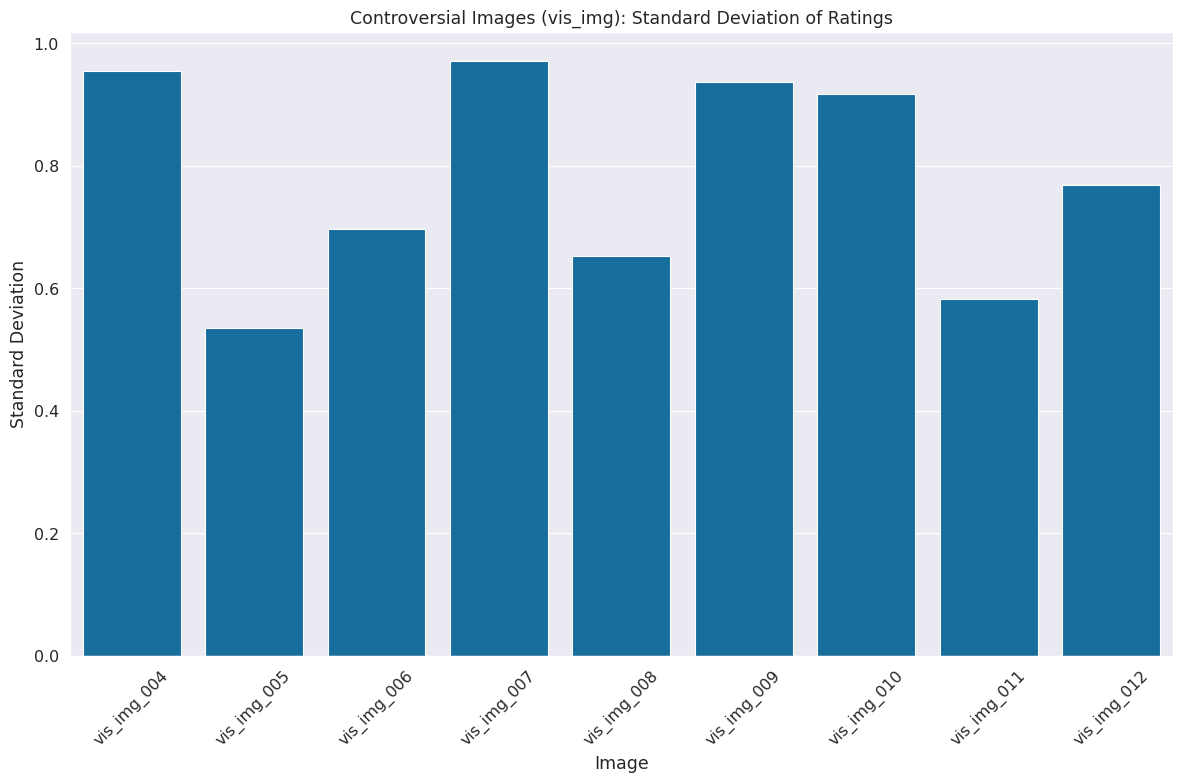

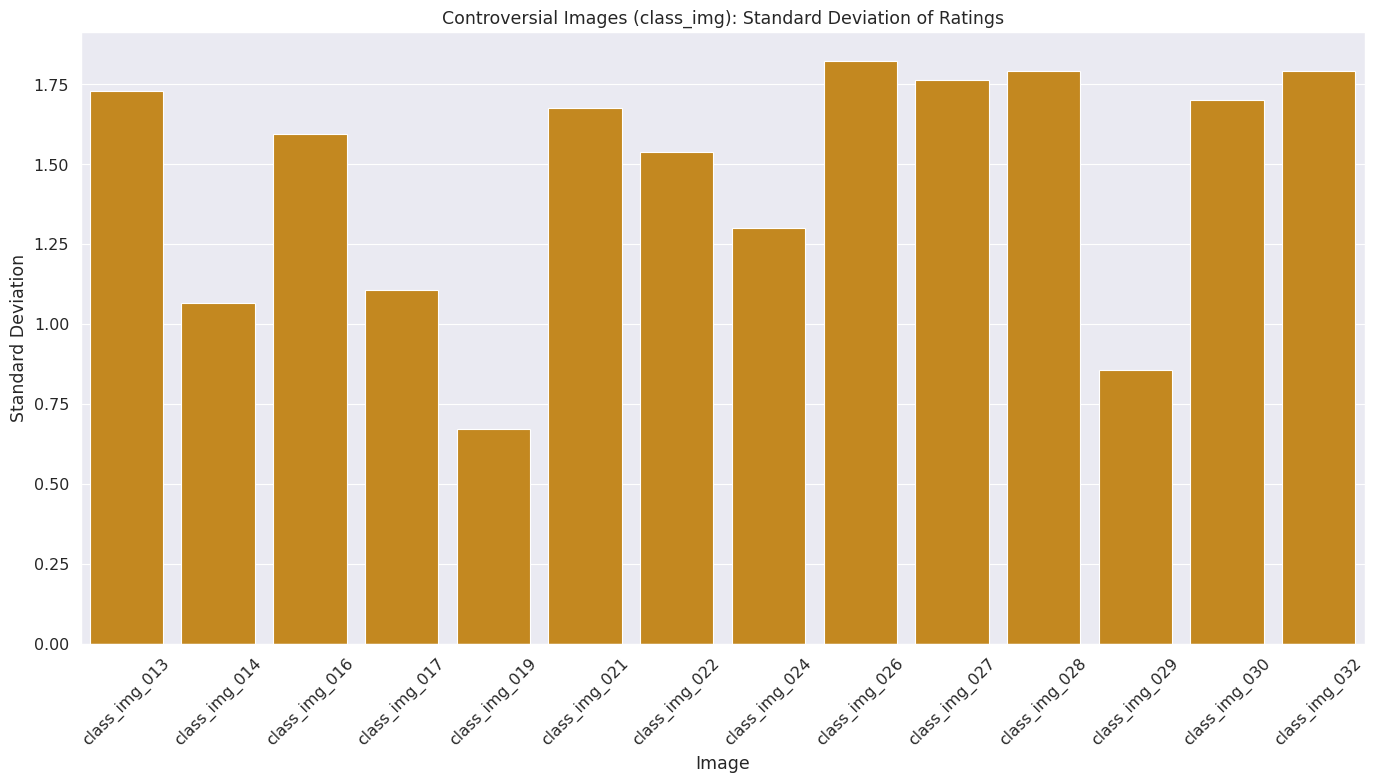

Standard deviation of ratings (class_img):
class_img_013    1.727
class_img_014    1.065
class_img_016    1.595
class_img_017    1.106
class_img_019    0.671
class_img_021    1.675
class_img_022    1.539
class_img_024    1.300
class_img_026    1.823
class_img_027    1.764
class_img_028    1.792
class_img_029    0.855
class_img_030    1.701
class_img_032    1.792
dtype: float64
Standard deviation of ratings (vis_img):
vis_img_004    0.955
vis_img_005    0.535
vis_img_006    0.697
vis_img_007    0.970
vis_img_008    0.653
vis_img_009    0.937
vis_img_010    0.918
vis_img_011    0.582
vis_img_012    0.769
dtype: float64


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("darkgrid")

# --- VIS_IMG ---
img_cols_vis = [col for col in df.columns if col.startswith("vis_img")]
df_vis = df[df['ID'] != 20][img_cols_vis]  # exclude ground truth
stds_vis = df_vis.std()

plt.figure(figsize=(12, 8))
sns.barplot(x=stds_vis.index, y=stds_vis.values, color=sns.color_palette("colorblind")[0])
plt.title("Controversial Images (vis_img): Standard Deviation of Ratings")
plt.ylabel("Standard Deviation")
plt.xlabel("Image")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "stddev_vis_img.tif"), dpi=400, bbox_inches='tight')
plt.show()

# --- CLASS_IMG ---
img_cols_class = [col for col in df.columns if col.startswith("class_img")]
df_class = df[df['ID'] != 20][img_cols_class]
stds_class = df_class.std()

plt.figure(figsize=(14, 8))
sns.barplot(x=stds_class.index, y=stds_class.values, color=sns.color_palette("colorblind")[1])
plt.title("Controversial Images (class_img): Standard Deviation of Ratings")
plt.ylabel("Standard Deviation")
plt.xlabel("Image")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "stddev_class_img.tif"), dpi=400, bbox_inches='tight')
plt.show()



# Print values
print("Standard deviation of ratings (class_img):")
print(stds_class.round(3))

print("Standard deviation of ratings (vis_img):")
print(stds_vis.round(3))

This script is designed to count how many times raters chose “unsure” when evaluating images:

Per rater → who tends to be more uncertain.

Per image → which images are most confusing for the raters.


In [31]:
import pandas as pd

# Load data
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Remove ground truth row
df_raters = df[df["ID"] != 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# Count Unsure per Rater
# ----------------------------
per_rater_unsure = []

for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # Count unsure in vis_img (encoded = 1)
    unsure_vis = (row[vis_cols] == 1).sum()

    # Count unsure in class_img (encoded = 4)
    unsure_class = (row[class_cols] == 4).sum()

    per_rater_unsure.append({
        "Rater_ID": rater_id,
        "Unsure_vis": unsure_vis,
        "Unsure_class": unsure_class
    })

per_rater_unsure_df = pd.DataFrame(per_rater_unsure)

# ----------------------------
# Count Unsure per Image
# ----------------------------
per_image_unsure = []

# vis_img
for col in vis_cols:
    unsure_count = (df_raters[col] == 1).sum()
    per_image_unsure.append({
        "Image": col,
        "Type": "vis_img",
        "Unsure_count": unsure_count
    })

# class_img
for col in class_cols:
    unsure_count = (df_raters[col] == 4).sum()
    per_image_unsure.append({
        "Image": col,
        "Type": "class_img",
        "Unsure_count": unsure_count
    })

per_image_unsure_df = pd.DataFrame(per_image_unsure)

# ----------------------------
# Show results
# ----------------------------
print("Unsure counts per rater:")
print(per_rater_unsure_df)

print("\nUnsure counts per image:")
print(per_image_unsure_df)


Unsure counts per rater:
    Rater_ID  Unsure_vis  Unsure_class
0          1           1             0
1          2           3             3
2          3           1             0
3          4           0             1
4          5           0             3
5          6           3             5
6          7           2             4
7          8           1             4
8          9           1             9
9         10           1             7
10        11           1             2
11        12           2             0
12        13           2             3
13        14           1             3
14        15           1             2
15        16           4             8
16        17           4             6
17        18           1            10
18        19           2             3

Unsure counts per image:
            Image       Type  Unsure_count
0     vis_img_004    vis_img             0
1     vis_img_005    vis_img             2
2     vis_img_006    vis_img            

This code generates a stacked bar visualization of rater responses per image, broken down into:

Agree (with ground truth),

Disagree (with ground truth),

Unsure (selected unsure option).

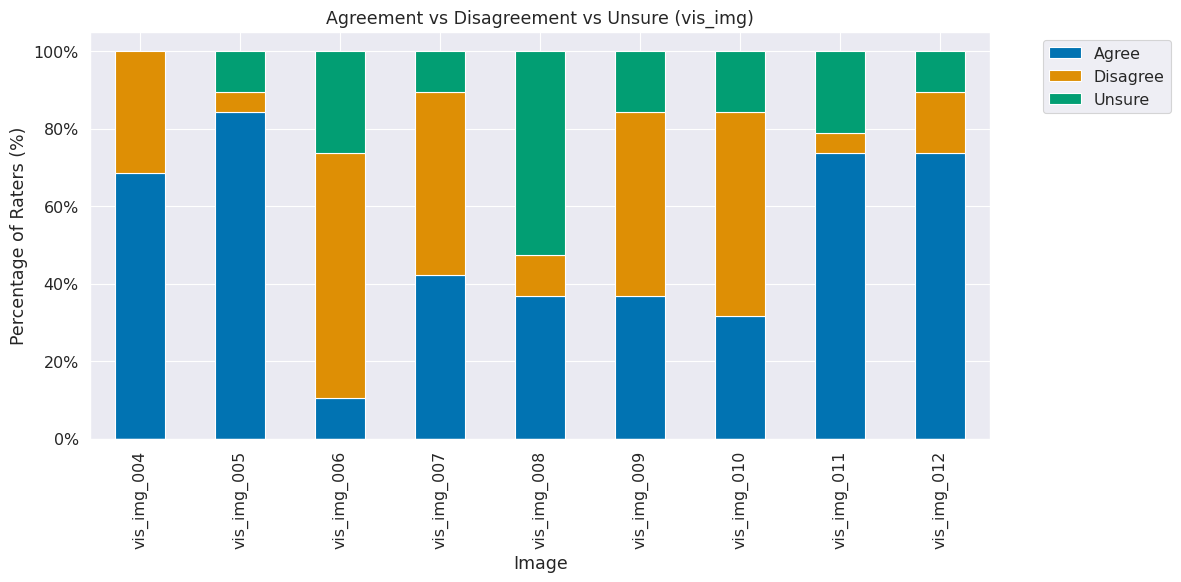

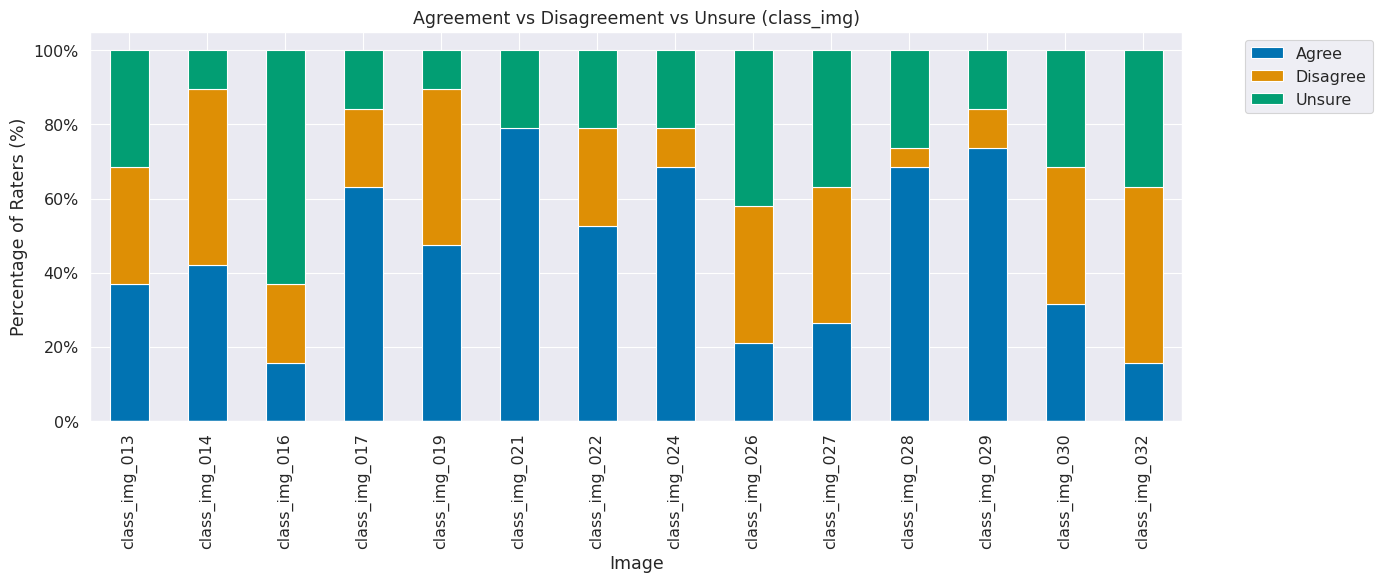

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

# --- Helper function to compute distributions per image ---
def compute_agreement_distribution(df_raters, df_gt, cols, unsure_code):
    results = []
    for col in cols:
        true_val = df_gt[col].iloc[0]
        ratings = df_raters[col]

        total = len(ratings)

        unsure = (ratings == unsure_code).sum() / total
        agree = (ratings == true_val).sum() / total
        disagree = 1 - (unsure + agree)

        results.append({
            "Image": col,
            "Agree": agree * 100,
            "Disagree": disagree * 100,
            "Unsure": unsure * 100
        })
    return pd.DataFrame(results)

# --- Compute for VIS_IMG and CLASS_IMG ---
vis_dist = compute_agreement_distribution(df_raters, df_gt, vis_cols, unsure_code=1)
class_dist = compute_agreement_distribution(df_raters, df_gt, class_cols, unsure_code=4)

sns.set_style("darkgrid")

# --- Plot stacked bar for VIS_IMG ---
ax = vis_dist.set_index("Image")[["Agree", "Disagree", "Unsure"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    color=sns.color_palette("colorblind", 3)
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("Agreement vs Disagreement vs Unsure (vis_img)")
plt.ylabel("Percentage of Raters (%)")
plt.xlabel("Image")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# --- Plot stacked bar for CLASS_IMG ---
ax = class_dist.set_index("Image")[["Agree", "Disagree", "Unsure"]].plot(
    kind="bar",
    stacked=True,
    figsize=(14,6),
    color=sns.color_palette("colorblind", 3)
)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.title("Agreement vs Disagreement vs Unsure (class_img)")
plt.ylabel("Percentage of Raters (%)")
plt.xlabel("Image")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


This script is a per-rater analysis of agreement, disagreement, and uncertaint.
It then creates a stacked bar chart per rater, with an extra colored rectangle under each rater ID showing their frost experience level, so you can visually compare performance vs. expertise.

Τhe degree of agreement, disagreement, and unsure is simply the percentage of images each rater rated as "correct" (vs ground truth), "wrong" (not equal to ground truth), or "unsure" (coded as 4).

Mounted at /content/drive


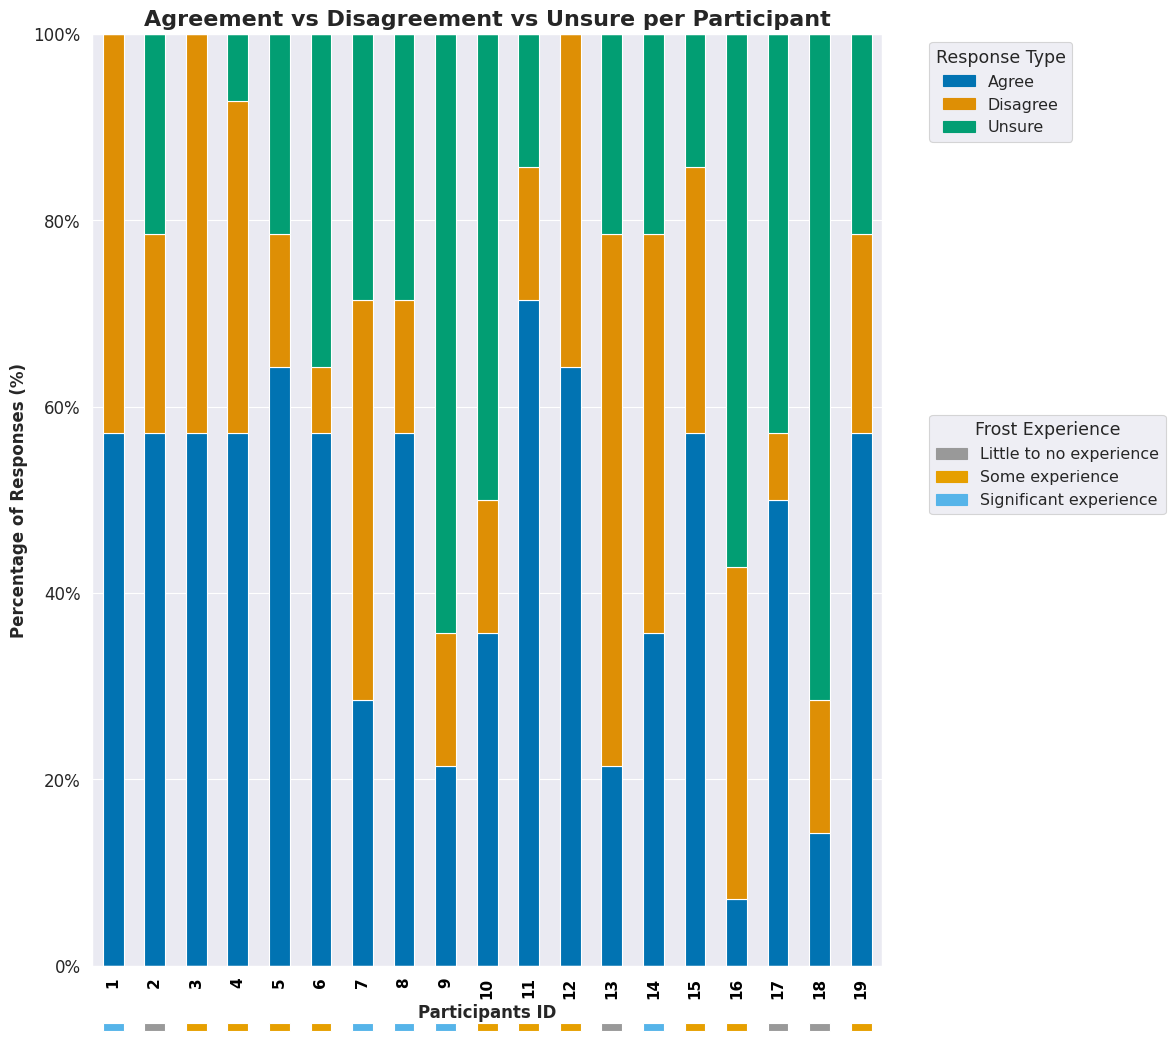


--- Agreement, Disagreement, and Uncertainty per Rater ---
 Rater_ID     Agree  Disagree    Unsure
        1 57.142857 42.857143  0.000000
        2 57.142857 21.428571 21.428571
        3 57.142857 42.857143  0.000000
        4 57.142857 35.714286  7.142857
        5 64.285714 14.285714 21.428571
        6 57.142857  7.142857 35.714286
        7 28.571429 42.857143 28.571429
        8 57.142857 14.285714 28.571429
        9 21.428571 14.285714 64.285714
       10 35.714286 14.285714 50.000000
       11 71.428571 14.285714 14.285714
       12 64.285714 35.714286  0.000000
       13 21.428571 57.142857 21.428571
       14 35.714286 42.857143 21.428571
       15 57.142857 28.571429 14.285714
       16  7.142857 35.714286 57.142857
       17 50.000000  7.142857 42.857143
       18 14.285714 14.285714 71.428571
       19 57.142857 21.428571 21.428571

--- Overall Degree of Agreement ---
Agreement:   45.86%
Disagreement:26.69%
Unsure:      27.44%


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.ticker as mtick
import os

# -------------------------------
# Helper: compute agreement distribution
# -------------------------------
def compute_rater_distribution(df_raters, df_gt, cols, unsure_code):
    results = []
    for idx, row in df_raters.iterrows():
        rater_id = row["ID"]

        agreements = []
        disagreements = []
        unsures = []

        for col in cols:
            true_val = df_gt[col].iloc[0]
            rating = row[col]
            if rating == unsure_code:
                unsures.append(1)
                agreements.append(0)
                disagreements.append(0)
            elif rating == true_val:
                agreements.append(1)
                disagreements.append(0)
                unsures.append(0)
            else:
                disagreements.append(1)
                agreements.append(0)
                unsures.append(0)

        results.append({
            "Rater_ID": rater_id,
            "Agree": np.mean(agreements) * 100,
            "Disagree": np.mean(disagreements) * 100,
            "Unsure": np.mean(unsures) * 100
        })
    return pd.DataFrame(results)

# -------------------------------
# Load data
# -------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

class_cols = [c for c in df.columns if c.startswith("class_img")]

# -------------------------------
# Compute distributions
# -------------------------------
rater_dist_class = compute_rater_distribution(df_raters, df_gt, class_cols, unsure_code=4)
rater_dist_class = rater_dist_class.merge(
    df_raters[["ID", "Experience with frost"]],
    left_on="Rater_ID", right_on="ID", how="left"
)

# -------------------------------
# Plotting
# -------------------------------
sns.set_style("darkgrid")

bar_palette = sns.color_palette("colorblind", 3)
frost_palette = {
    "Little to no experience": "#999999",  # grey
    "Some experience": "#E69F00",          # orange
    "Significant experience": "#56B4E9"    # blue
}

ax = rater_dist_class.set_index("Rater_ID")[["Agree", "Disagree", "Unsure"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12,10.5),
    color=bar_palette
)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.title("Agreement vs Disagreement vs Unsure per Participant", fontsize=16, fontweight="bold")
plt.ylabel("Percentage of Responses (%)", fontsize=12, fontweight="bold")
plt.xlabel("Participants ID", fontsize=12, fontweight="bold")

# Increase tick label size too
ax.tick_params(axis='both', labelsize=12)

# Set custom x-ticks with larger font
ax.set_xticks(range(len(rater_dist_class)))
ax.set_xticklabels(rater_dist_class["Rater_ID"], fontsize=11, fontweight="bold", color="black")

# Add colored rectangles below the rater IDs
rect_height = 0.9   # rectangle thickness
rect_width = 0.5  # width relative to bar
y_pos = -7        # vertical position

for i, exp in enumerate(rater_dist_class["Experience with frost"]):
    rect = plt.Rectangle(
        (i - rect_width/2, y_pos),  # x,y bottom left
        rect_width,
        rect_height,
        facecolor=frost_palette[exp],
        #edgecolor="black",
        clip_on=False,
        zorder=3
    )
    ax.add_patch(rect)

# Keep y-axis fixed
ax.set_ylim(0, 100)

# Legends
bar_handles = [mpatches.Patch(color=bar_palette[i], label=label)
               for i, label in enumerate(["Agree", "Disagree", "Unsure"])]
frost_handles = [mpatches.Patch(color=color, label=exp) for exp, color in frost_palette.items()]

legend1 = plt.legend(handles=bar_handles, title="Response Type",
                     bbox_to_anchor=(1.05, 1), loc="upper left")
plt.gca().add_artist(legend1)
plt.legend(handles=frost_handles, title="Frost Experience",
           bbox_to_anchor=(1.05, 0.6), loc="upper left")

plt.tight_layout()
plt.savefig(os.path.join("/content/drive/My Drive", "agreement_per_rater_classimg_rectangles_labels.tif"),
            dpi=400, bbox_inches='tight')
plt.show()


# -------------------------------
# Print overall and per-rater summary
# -------------------------------

# Print per-rater percentages
print("\n--- Agreement, Disagreement, and Uncertainty per Rater ---")
print(rater_dist_class[["Rater_ID", "Agree", "Disagree", "Unsure"]].to_string(index=False))

# Compute overall averages across all raters
overall = rater_dist_class[["Agree", "Disagree", "Unsure"]].mean()
print("\n--- Overall Degree of Agreement ---")
print(f"Agreement:   {overall['Agree']:.2f}%")
print(f"Disagreement:{overall['Disagree']:.2f}%")
print(f"Unsure:      {overall['Unsure']:.2f}%")


This code snippset here is a correlation analysis script: it checks whether images with higher variability (standard deviation) among raters tend to have lower agreement with the ground truth.

This code analyzes the relationship between:

Agreement with ground truth (accuracy of raters),

Variability among raters (std dev).

It then:

Computes Spearman correlations,

Visualizes the relationship per image (scatterplots),

Summarizes ranges and per-image data.

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from google.colab import drive
import os

# ----------------------------
# Mount Google Drive
# ----------------------------
drive.mount('/content/drive')

# ----------------------------
# Load data
# ----------------------------
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# Calculate agreement and standard deviation per image
# ----------------------------
correlation_data = []

# VIS_IMG
for col in vis_cols:
    true_val = df_gt[col].iloc[0]
    rater_responses = df_raters[col].values

    agreement = (rater_responses == true_val).mean() * 100  # %
    std_dev = np.std(rater_responses, ddof=1)  # sample std dev

    correlation_data.append({
        "Image": col,
        "Type": "Visibility",
        "Agreement": agreement,
        "StdDev": std_dev
    })

# CLASS_IMG
for col in class_cols:
    true_val = df_gt[col].iloc[0]
    rater_responses = df_raters[col].values

    agreement = (rater_responses == true_val).mean() * 100  # %
    std_dev = np.std(rater_responses, ddof=1)

    correlation_data.append({
        "Image": col,
        "Type": "Classification",
        "Agreement": agreement,
        "StdDev": std_dev
    })

# Convert to DataFrame
correlation_df = pd.DataFrame(correlation_data)

# ----------------------------
# Calculate correlation coefficients
# ----------------------------
vis_data = correlation_df[correlation_df['Type'] == 'Visibility']
class_data = correlation_df[correlation_df['Type'] == 'Classification']

vis_corr, vis_p = spearmanr(vis_data['StdDev'], vis_data['Agreement'])
class_corr, class_p = spearmanr(class_data['StdDev'], class_data['Agreement'])
overall_corr, overall_p = spearmanr(correlation_df['StdDev'], correlation_df['Agreement'])

print("Spearman Correlation Results:")
print(f"Visibility Task: ρ = {vis_corr:.3f}, p = {vis_p:.3f}")
print(f"Classification Task: ρ = {class_corr:.3f}, p = {class_p:.3f}")
print(f"Overall: ρ = {overall_corr:.3f}, p = {overall_p:.3f}")

# ----------------------------
# Print summary statistics
# ----------------------------
print("\nSummary Statistics:")
print(f"Visibility Task - Agreement range: {vis_data['Agreement'].min():.1f}% - {vis_data['Agreement'].max():.1f}%")
print(f"Visibility Task - Std Dev range: {vis_data['StdDev'].min():.3f} - {vis_data['StdDev'].max():.3f}")
print(f"Classification Task - Agreement range: {class_data['Agreement'].min():.1f}% - {class_data['Agreement'].max():.1f}%")
print(f"Classification Task - Std Dev range: {class_data['StdDev'].min():.3f} - {class_data['StdDev'].max():.3f}")

# ----------------------------
# Optional: Save correlation data
# ----------------------------
print("\nCorrelation Data:")
print(correlation_df.round(3))
# correlation_df.to_excel('correlation_analysis.xlsx', index=False)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Spearman Correlation Results:
Visibility Task: ρ = -0.328, p = 0.389
Classification Task: ρ = -0.441, p = 0.115
Overall: ρ = -0.371, p = 0.081

Summary Statistics:
Visibility Task - Agreement range: 10.5% - 84.2%
Visibility Task - Std Dev range: 0.535 - 0.970
Classification Task - Agreement range: 15.8% - 78.9%
Classification Task - Std Dev range: 0.671 - 1.823

Correlation Data:
            Image            Type  Agreement  StdDev
0     vis_img_004      Visibility     68.421   0.955
1     vis_img_005      Visibility     84.211   0.535
2     vis_img_006      Visibility     10.526   0.697
3     vis_img_007      Visibility     42.105   0.970
4     vis_img_008      Visibility     36.842   0.653
5     vis_img_009      Visibility     36.842   0.937
6     vis_img_010      Visibility     31.579   0.918
7     vis_img_011      Visibility     73.684   0.582
8     vis_i

In [35]:
!pip install adjustText

In [36]:
# Install if needed
!pip install upsetplot -q

Quantifies how consistently participants rated each image and tests whether
images with more disagreement also show lower consensus, then visualizes this
relationship for visibility vs classification tasks.

This cell:
1. For each visibility image and each classification image, extracts all
   participant ratings, computes (a) the majority-vote consensus (most common
   rating) and the percentage of raters who selected it as an agreement score,
   and (b) the standard deviation of ratings as a measure of response
   variability, and stores these per-image metrics in a summary DataFrame.
2. Computes Spearman rank correlations between the standard deviation and the
   agreement percentage separately for visibility and classification images,
   as well as overall, to test whether images with higher variability tend to
   have lower consensus, and prints the corresponding correlation coefficients
   and p-values.
3. Creates an enhanced scatter plot with larger, colorblind-safe points showing
   each image’s variability vs agreement (blue for visibility, orange/red for
   classification), annotates each point with a cleaned image label using
   `adjust_text` to reduce overlap, and styles the figure with larger fonts,
   axis limits, and a detailed legend.
4. Saves the resulting figure as a high-resolution .tif file to Google Drive,
   providing a publication-ready visualization of the link between response
   variability and consensus across the two rating tasks.

Spearman Correlation Results (Across Raters):
Visibility Task: ρ = -0.675, p = 0.046
Classification Task: ρ = -0.361, p = 0.205
Overall: ρ = -0.486, p = 0.019


/tmp/ipykernel_870/2064209732.py:77: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.

/tmp/ipykernel_870/2064209732.py:82: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.



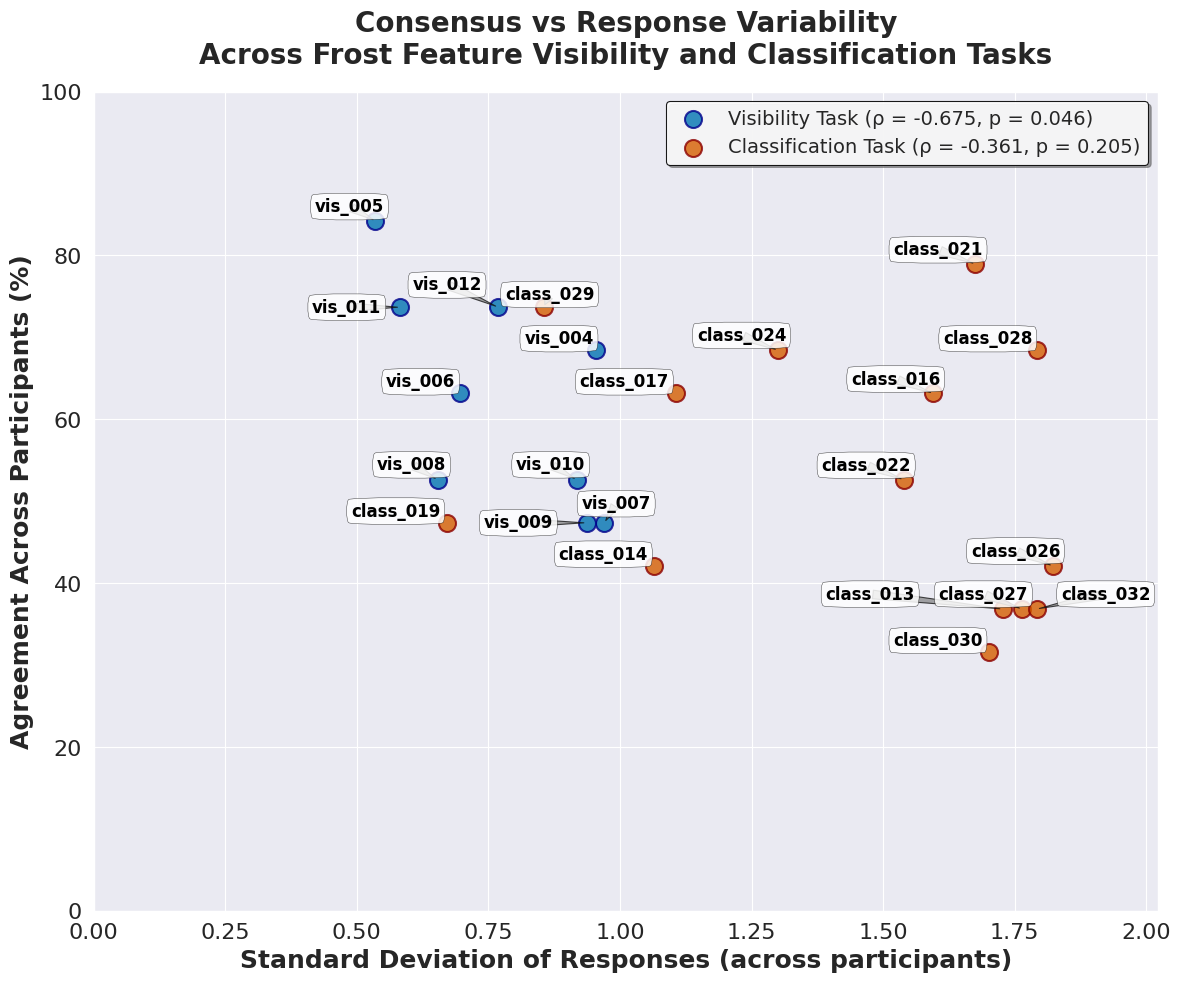

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from adjustText import adjust_text
import os

# ----------------------------
# Calculate agreement (across raters) and standard deviation per image
# ----------------------------
correlation_data = []

# VIS_IMG
for col in vis_cols:
    responses = df_raters[col].astype(int).values

    # Agreement across raters (majority vote consensus)
    majority_val = pd.Series(responses).mode().iloc[0]
    agreement_across = (responses == majority_val).mean() * 100  # %

    # Variability across raters
    std_dev = np.std(responses, ddof=1)

    correlation_data.append({
        "Image": col,
        "Type": "Visibility",
        "Agreement": agreement_across,
        "StdDev": std_dev
    })

# CLASS_IMG
for col in class_cols:
    responses = df_raters[col].astype(int).values

    majority_val = pd.Series(responses).mode().iloc[0]
    agreement_across = (responses == majority_val).mean() * 100

    std_dev = np.std(responses, ddof=1)

    correlation_data.append({
        "Image": col,
        "Type": "Classification",
        "Agreement": agreement_across,
        "StdDev": std_dev
    })

correlation_df = pd.DataFrame(correlation_data)

# ----------------------------
# Calculate correlation coefficients (StdDev vs Consensus)
# ----------------------------
vis_data = correlation_df[correlation_df['Type'] == 'Visibility']
class_data = correlation_df[correlation_df['Type'] == 'Classification']

vis_corr, vis_p = spearmanr(vis_data['StdDev'], vis_data['Agreement'])
class_corr, class_p = spearmanr(class_data['StdDev'], class_data['Agreement'])
overall_corr, overall_p = spearmanr(correlation_df['StdDev'], correlation_df['Agreement'])

print("Spearman Correlation Results (Across Raters):")
print(f"Visibility Task: ρ = {vis_corr:.3f}, p = {vis_p:.3f}")
print(f"Classification Task: ρ = {class_corr:.3f}, p = {class_p:.3f}")
print(f"Overall: ρ = {overall_corr:.3f}, p = {overall_p:.3f}")

# ----------------------------
# Create scatter plot
# ----------------------------
plt.figure(figsize=(12, 10))  # INCREASED figure size
sns.set_style("darkgrid")
sns.set_palette("colorblind")

colors = sns.color_palette("colorblind")
vis_color = colors[0]   # blue
class_color = colors[3] # orange/red

# Scatter plots with LARGER points
plt.scatter(vis_data['StdDev'], vis_data['Agreement'],
            c=vis_color, s=150, alpha=0.8,  # INCREASED from 80 to 150
            label=f'Visibility Task (ρ = {vis_corr:.3f}, p = {vis_p:.3f})',
            edgecolors='darkblue', linewidth=1.5)

plt.scatter(class_data['StdDev'], class_data['Agreement'],
            c=class_color, s=150, alpha=0.8,  # INCREASED from 80 to 150
            label=f'Classification Task (ρ = {class_corr:.3f}, p = {class_p:.3f})',
            edgecolors='darkred', linewidth=1.5)

# Axes and title with LARGER fonts
plt.xlabel('Standard Deviation of Responses (across participants)', fontsize=18, fontweight='bold')  # INCREASED from 13 to 18
plt.ylabel('Agreement Across Participants (%)', fontsize=18, fontweight='bold')  # INCREASED from 13 to 18
plt.title('Consensus vs Response Variability\nAcross Frost Feature Visibility and Classification Tasks',
          fontsize=20, fontweight='bold', pad=20)  # INCREASED from 15 to 20

# Increase tick label sizes
plt.tick_params(axis='both', labelsize=16)  # ADDED this line

# Legend with LARGER font
plt.legend(fontsize=14, loc='upper right', fancybox=True, shadow=True,  # INCREASED from 10 to 14
           frameon=True, facecolor='white', edgecolor='black', framealpha=0.9)

# Axis limits
plt.xlim(0, max(correlation_df['StdDev']) + 0.2)
plt.ylim(0, 100)

# Labels with adjust_text - LARGER font
texts = []
for _, row in correlation_df.iterrows():
    clean_name = row['Image'].replace('_img_', '_')
    texts.append(
        plt.text(row['StdDev'], row['Agreement'],
                 clean_name,
                 ha="right", va="bottom",
                 fontsize=12, fontweight="bold", color="black",  # INCREASED from 9 to 12
                 bbox=dict(boxstyle='round4,pad=0.3',  # Slightly larger padding
                           facecolor='white', alpha=0.85,  # Slightly more transparent
                           edgecolor='black', linewidth=0.3),
                 zorder=10)  # ADDED zorder to control layering
    )

# Adjust text with more flexibility for overlapping
adjust_text(texts,
            arrowprops=dict(arrowstyle="wedge,tail_width=0.5",
                facecolor="gray", edgecolor="black", alpha=0.7),
            expand_points=(1.5, 1.5),  # ADDED: more space around points
            force_text=(0.5, 0.5),  # ADDED: reduced force to allow some overlap
            force_points=(0.3, 0.3))  # ADDED: reduced force on points

plt.tight_layout()
plt.savefig(os.path.join("/content/drive/My Drive",
                         "2sp_correlation_st_dev_vs_across_raters_clean_labels.tif"),
            dpi=400, bbox_inches='tight')
plt.show()

Computes per-participant agreement and reliability metrics for visibility and
classification ratings against both ground truth and group consensus.

This script:
1. Loads a voting spreadsheet where one special row (ID=20) encodes the
   ground-truth labels for all visibility (`vis_img*`) and classification
   (`class_img*`) items, separates that row from the remaining participants,
   and defines column groups for the two tasks.
2. Computes global inter-rater reliability using Fleiss’ kappa separately for
   the visibility and classification tasks by building image × category count
   matrices from all raters’ responses, providing an overall measure of
   consistency across participants.
3. For each participant, calculates:
   - Cohen’s kappa against the ground truth for visibility and classification,
   - Percentage agreement with the ground truth (how often they match GT),
   - Percentage agreement with the majority vote across participants (how often
     they match the group consensus),
   - Percentage of disagreements (responses that differ from GT and are not
     marked as “unsure”),
   - Percentage of “unsure” answers (assuming 0 encodes uncertainty),
   and stores all these metrics in a comprehensive per-participant results
   table.
4. Prints the full participant-level metrics table, saves it as
   `comprehensive_participant_metrics.xlsx` to Google Drive, and outputs
   summary statistics (e.g. means, standard deviations) so that individual
   rating behavior, agreement with ground truth, inter-rater reliability, and
   uncertainty patterns can be inspected quantitatively.

In [38]:
import numpy as np
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

# Mount Google Drive
drive.mount('/content/drive')

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# Extract ground truth (ID = 20)
ground_truth = df[df["ID"] == 20]

# Remove ground truth row for raters
df_raters = df[df["ID"] != 20]

# Define column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# Output directory
output_dir = "/content/drive/My Drive"
os.makedirs(output_dir, exist_ok=True)

sns.set_style("darkgrid")

# ===================================================================
# CREATE COMPREHENSIVE DATAFRAME WITH ALL METRICS
# ===================================================================

# Initialize list to store results
results_list = []

# Get ground truth values
gt_vis = ground_truth[vis_cols].values.flatten().astype(int)
gt_class = ground_truth[class_cols].values.flatten().astype(int)

# Calculate Fleiss Kappa (same for all participants, calculated once)
def calculate_fleiss_kappa(df_raters, cols):
    """Calculate Fleiss Kappa for a set of columns"""
    # Create matrix: rows = images, columns = categories
    responses = df_raters[cols].values.astype(int)
    n_raters, n_items = responses.shape

    # Determine unique categories
    categories = np.unique(responses)
    n_categories = len(categories)

    # Create count matrix
    count_matrix = np.zeros((n_items, n_categories))
    for i in range(n_items):
        for cat_idx, cat in enumerate(categories):
            count_matrix[i, cat_idx] = np.sum(responses[:, i] == cat)

    # Calculate Fleiss Kappa
    fk = fleiss_kappa(count_matrix)
    return fk

fleiss_kappa_vis = calculate_fleiss_kappa(df_raters, vis_cols)
fleiss_kappa_class = calculate_fleiss_kappa(df_raters, class_cols)

print(f"Fleiss Kappa (Visibility): {fleiss_kappa_vis:.4f}")
print(f"Fleiss Kappa (Classification): {fleiss_kappa_class:.4f}")

# Calculate majority vote for agreement across participants
majority_vis = []
for col in vis_cols:
    mode_val = df_raters[col].astype(int).mode().iloc[0]
    majority_vis.append(mode_val)

majority_class = []
for col in class_cols:
    mode_val = df_raters[col].astype(int).mode().iloc[0]
    majority_class.append(mode_val)

# Iterate through each participant
for idx, row in df_raters.iterrows():
    participant_id = row['ID']

    # Get participant responses
    rater_vis = row[vis_cols].values.astype(int)
    rater_class = row[class_cols].values.astype(int)

    # ===== COHEN'S KAPPA AGAINST GROUND TRUTH =====
    cohens_kappa_vis = cohen_kappa_score(gt_vis, rater_vis)
    cohens_kappa_class = cohen_kappa_score(gt_class, rater_class)

    # ===== AGREEMENT AGAINST GROUND TRUTH (%) =====
    agreement_gt_vis = (rater_vis == gt_vis).mean() * 100
    agreement_gt_class = (rater_class == gt_class).mean() * 100

    # ===== AGREEMENT ACROSS PARTICIPANTS (%) =====
    # Agreement with majority vote
    agreement_across_vis = (rater_vis == majority_vis).mean() * 100
    agreement_across_class = (rater_class == majority_class).mean() * 100

    # ===== DISAGREEMENT (%) =====
    # Disagreement = NOT matching ground truth
    disagreement_vis = ((rater_vis != gt_vis) & (rater_vis != 0)).mean() * 100  # Excluding unsure
    disagreement_class = ((rater_class != gt_class) & (rater_class != 0)).mean() * 100  # Excluding unsure

    # ===== UNSURE ANSWERS (%) =====
    # Assuming 0 = Unsure (adjust if different)
    unsure_vis = (rater_vis == 0).mean() * 100
    unsure_class = (rater_class == 0).mean() * 100

    # Append to results
    results_list.append({
        'Participant_ID': participant_id,
        'Cohens_Kappa_Vis': cohens_kappa_vis,
        'Cohens_Kappa_Class': cohens_kappa_class,
        'Agreement_Across_Participants_Vis_%': agreement_across_vis,
        'Agreement_Across_Participants_Class_%': agreement_across_class,
        'Agreement_vs_GroundTruth_Vis_%': agreement_gt_vis,
        'Agreement_vs_GroundTruth_Class_%': agreement_gt_class,
        'Fleiss_Kappa_Vis': fleiss_kappa_vis,
        'Fleiss_Kappa_Class': fleiss_kappa_class,
        'Disagreement_Vis_%': disagreement_vis,
        'Disagreement_Class_%': disagreement_class,
        'Unsure_Vis_%': unsure_vis,
        'Unsure_Class_%': unsure_class
    })

# Create comprehensive dataframe
comprehensive_df = pd.DataFrame(results_list)

# Display the dataframe
print("\n" + "="*80)
print("COMPREHENSIVE PARTICIPANT METRICS")
print("="*80)
print(comprehensive_df.to_string(index=False))

# Save to Excel
output_path = os.path.join(output_dir, 'comprehensive_participant_metrics.xlsx')
comprehensive_df.to_excel(output_path, index=False)
print(f"\nDataframe saved to: {output_path}")

# Display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(comprehensive_df.describe())

# Optional: Create a nice formatted display
print("\n" + "="*80)
print("ROUNDED DISPLAY (2 decimal places)")
print("="*80)
print(comprehensive_df.round(2).to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fleiss Kappa (Visibility): 0.1499
Fleiss Kappa (Classification): 0.2078

COMPREHENSIVE PARTICIPANT METRICS
 Participant_ID  Cohens_Kappa_Vis  Cohens_Kappa_Class  Agreement_Across_Participants_Vis_%  Agreement_Across_Participants_Class_%  Agreement_vs_GroundTruth_Vis_%  Agreement_vs_GroundTruth_Class_%  Fleiss_Kappa_Vis  Fleiss_Kappa_Class  Disagreement_Vis_%  Disagreement_Class_%  Unsure_Vis_%  Unsure_Class_%
              1               0.0            0.416667                            66.666667                              78.571429                       55.555556                         57.142857          0.149872             0.20776           11.111111              0.000000     33.333333       64.285714
              2               0.0            0.358779                            66.666667                              57.142857                       

Examines how participants’ frost experience relates to how often they answer
“unsure” in the visibility and classification tasks, and tests whether these
differences are statistically significant.

This cell:
1. Merges the per-participant metrics table with each rater’s self-reported
   frost experience level, creating a combined DataFrame that includes
   percentages of unsure responses plus an experience category for every
   participant.
2. Produces side-by-side box+strip plots showing the distribution of unsure
   response rates across three experience levels (“Little to no experience”,
   “Some experience”, “Significant experience”) separately for the visibility
   and classification tasks, saving a high-resolution .tif figure suitable for
   publication.
3. Prints summary statistics (mean, median, standard deviation, min, max) of
   unsure-response percentages by experience group for each task, making it
   easy to see how uncertainty varies with expertise.
4. Applies Kruskal–Wallis tests across the three experience groups for both
   tasks, reports the test statistics and p-values, and flags whether there are
   statistically significant differences in unsure-response rates between
   experience levels.

/tmp/ipykernel_870/2710991014.py:15: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_870/2710991014.py:36: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_870/2710991014.py:41: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_870/2710991014.py:62: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



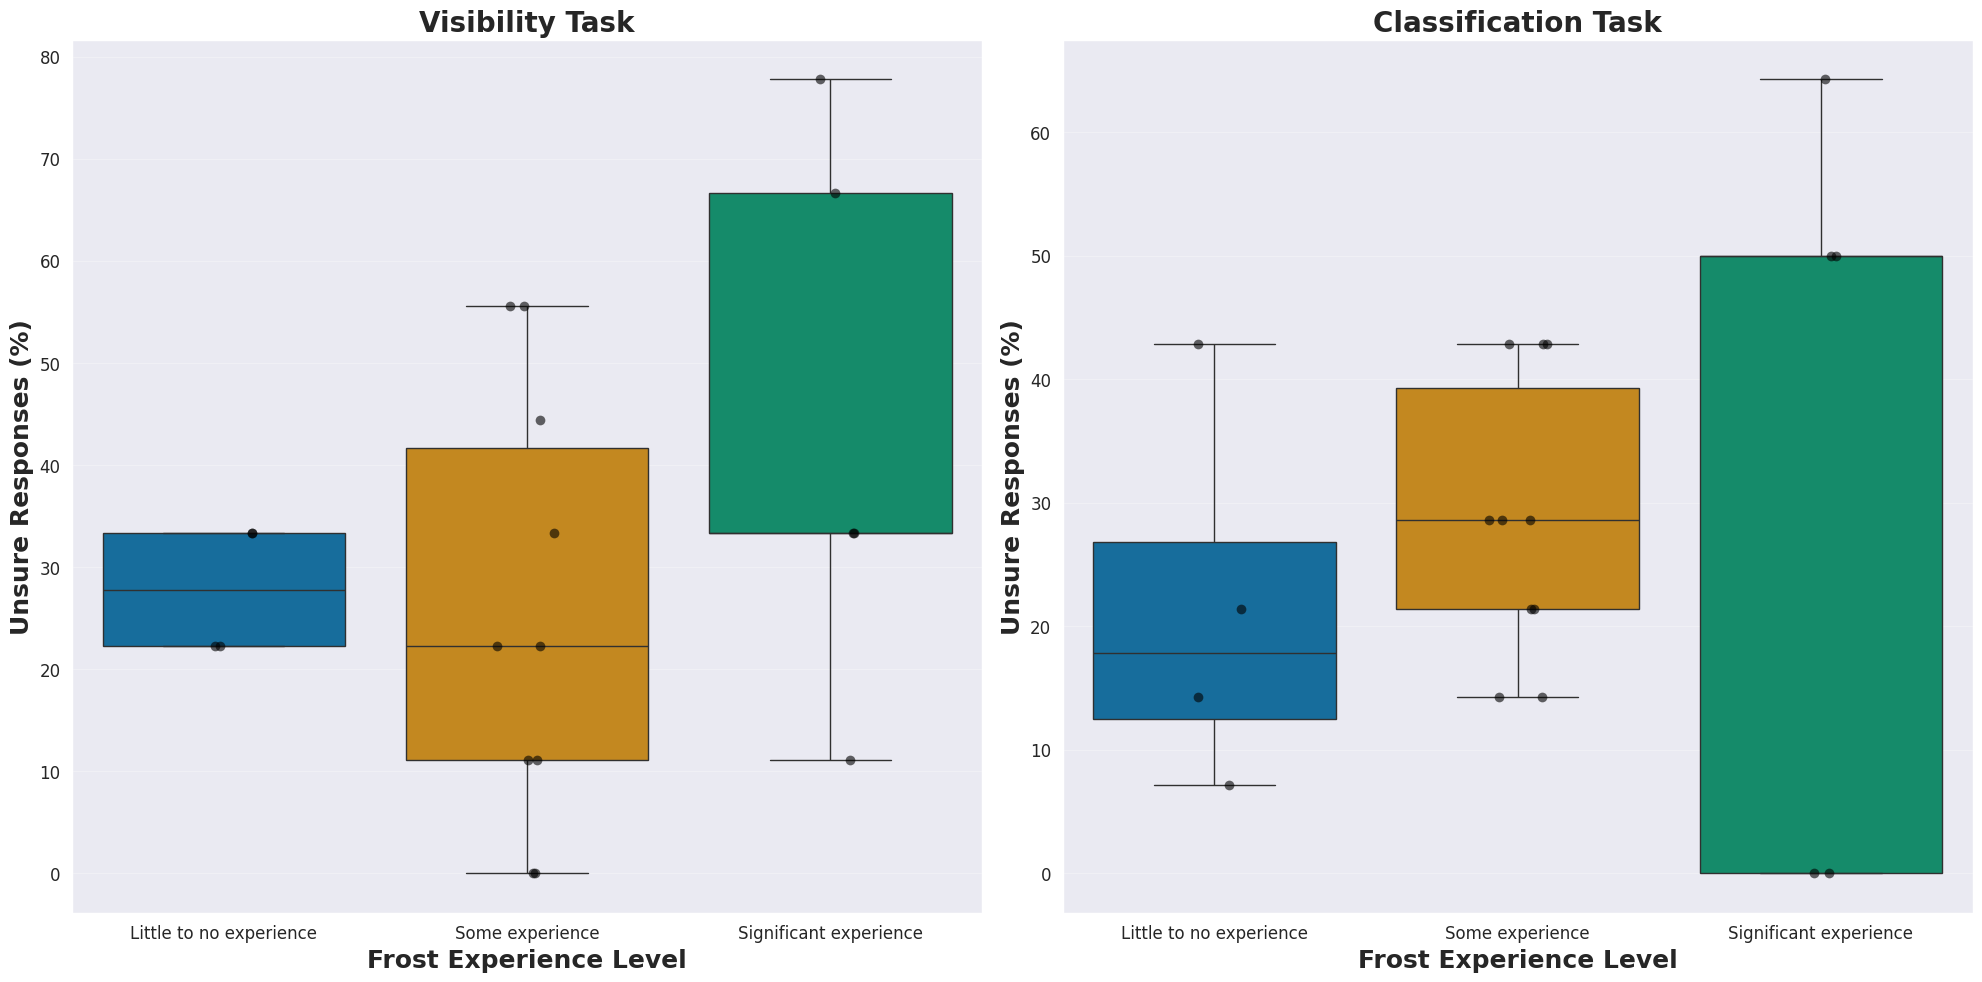


UNSURE RESPONSES BY FROST EXPERIENCE LEVEL

Visibility Task:
--------------------------------------------------------------------------------
                          mean  median    std    min    max
Experience with frost                                      
Little to no experience  27.78   27.78   6.42  22.22  33.33
Some experience          25.56   22.22  20.98   0.00  55.56
Significant experience   44.44   33.33  27.22  11.11  77.78

Classification Task:
--------------------------------------------------------------------------------
                          mean  median    std    min    max
Experience with frost                                      
Little to no experience  21.43   17.86  15.43   7.14  42.86
Some experience          28.57   28.57  11.17  14.29  42.86
Significant experience   32.86   50.00  30.56   0.00  64.29

STATISTICAL TESTS (Kruskal-Wallis)

Visibility Task: H = 2.115, p = 0.3474
  → No significant difference between groups

Classification Task: H = 1.064, 

In [39]:
# Merge frost experience into comprehensive dataframe
comprehensive_df_with_experience = comprehensive_df.merge(
    df_raters[["ID", "Experience with frost"]],
    left_on="Participant_ID", right_on="ID", how="left"
)

# Box plot: Unsure responses by frost experience (2 subplots)
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

colors = sns.color_palette('colorblind')
experience_order = ["Little to no experience", "Some experience", "Significant experience"]

# ===== VISIBILITY TASK =====
ax = axes[0]
sns.boxplot(
    data=comprehensive_df_with_experience,
    x="Experience with frost",
    y="Unsure_Vis_%",
    palette="colorblind",
    order=experience_order,
    ax=ax
)
sns.stripplot(
    data=comprehensive_df_with_experience,
    x="Experience with frost",
    y="Unsure_Vis_%",
    color="black", size=7, alpha=0.6,
    order=experience_order,
    ax=ax
)

ax.set_xlabel('Frost Experience Level', fontsize=18, fontweight='bold')
ax.set_ylabel('Unsure Responses (%)', fontsize=18, fontweight='bold')
ax.set_title('Visibility Task', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.grid(axis='y', alpha=0.3)

# ===== CLASSIFICATION TASK =====
ax = axes[1]
sns.boxplot(
    data=comprehensive_df_with_experience,
    x="Experience with frost",
    y="Unsure_Class_%",
    palette="colorblind",
    order=experience_order,
    ax=ax
)
sns.stripplot(
    data=comprehensive_df_with_experience,
    x="Experience with frost",
    y="Unsure_Class_%",
    color="black", size=7, alpha=0.6,
    order=experience_order,
    ax=ax
)

ax.set_xlabel('Frost Experience Level', fontsize=18, fontweight='bold')
ax.set_ylabel('Unsure Responses (%)', fontsize=18, fontweight='bold')
ax.set_title('Classification Task', fontsize=20, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center')
ax.grid(axis='y', alpha=0.3)


plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'unsure_by_frost_experience.tif'), dpi=400, bbox_inches='tight')
plt.show()

# Print summary statistics by frost experience
print("\n" + "="*80)
print("UNSURE RESPONSES BY FROST EXPERIENCE LEVEL")
print("="*80)

for task_name, col_name in [('Visibility Task', 'Unsure_Vis_%'),
                             ('Classification Task', 'Unsure_Class_%')]:
    print(f"\n{task_name}:")
    print("-" * 80)
    summary = comprehensive_df_with_experience.groupby('Experience with frost')[col_name].agg(['mean', 'median', 'std', 'min', 'max'])
    summary = summary.reindex(experience_order)
    print(summary.round(2))

# Optional: Statistical test (Kruskal-Wallis) to see if differences are significant
from scipy.stats import kruskal

print("\n" + "="*80)
print("STATISTICAL TESTS (Kruskal-Wallis)")
print("="*80)

# Test for Visibility
groups_vis = [
    comprehensive_df_with_experience[comprehensive_df_with_experience['Experience with frost'] == exp]['Unsure_Vis_%'].values
    for exp in experience_order
]
stat_vis, p_vis = kruskal(*groups_vis)
print(f"\nVisibility Task: H = {stat_vis:.3f}, p = {p_vis:.4f}")
if p_vis < 0.05:
    print("  → Significant difference between groups!")
else:
    print("  → No significant difference between groups")

# Test for Classification
groups_class = [
    comprehensive_df_with_experience[comprehensive_df_with_experience['Experience with frost'] == exp]['Unsure_Class_%'].values
    for exp in experience_order
]
stat_class, p_class = kruskal(*groups_class)
print(f"\nClassification Task: H = {stat_class:.3f}, p = {p_class:.4f}")
if p_class < 0.05:
    print("  → Significant difference between groups!")
else:
    print("  → No significant difference between groups")

Builds a per-participant reliability and agreement profile for visibility and
classification ratings, relative to both ground truth and group consensus.

This cell:
1. Loads a rating spreadsheet where a dedicated row (ID=20) provides ground-
   truth labels for all visibility (`vis_img*`) and classification (`class_img*`)
   items, separates this from the remaining participants, and identifies the
   relevant visibility and classification columns.
2. Computes global inter-rater reliability for each task via Fleiss’ kappa by
   turning all raters’ responses into image × category count matrices, then
   prints a single Fleiss’ kappa value for visibility and classification,
   respectively.
3. For each participant, derives:
   - Cohen’s kappa vs ground truth for visibility and classification,
   - Percentage agreement with the ground truth (how often they match GT),
   - Percentage agreement with the majority vote across participants,
   - Percentage of disagreements (non-GT responses excluding “unsure”),
   - Percentage of “unsure” responses (assuming 0 encodes uncertainty),
   and stores these metrics in a comprehensive participant-level DataFrame.
4. Prints the full table, saves both the original and a rounded (2 decimal
   places) version to separate Excel files in Google Drive, and outputs
   summary statistics so that individual reliability, agreement, disagreement,
   and uncertainty patterns can be inspected quantitatively.

In [40]:
import numpy as np
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.metrics import cohen_kappa_score
from statsmodels.stats.inter_rater import fleiss_kappa

# Mount Google Drive
drive.mount('/content/drive')

# Path to your Excel file
file_path = '/content/drive/My Drive/voting_poll.xlsx'

# Load Excel file
df = pd.read_excel(file_path, sheet_name='results')

# Extract ground truth (ID = 20)
ground_truth = df[df["ID"] == 20]

# Remove ground truth row for raters
df_raters = df[df["ID"] != 20]

# Define column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# Output directory
output_dir = "/content/drive/My Drive"
os.makedirs(output_dir, exist_ok=True)

sns.set_style("darkgrid")

# ===================================================================
# CREATE COMPREHENSIVE DATAFRAME WITH ALL METRICS
# ===================================================================

# Initialize list to store results
results_list = []

# Get ground truth values
gt_vis = ground_truth[vis_cols].values.flatten().astype(int)
gt_class = ground_truth[class_cols].values.flatten().astype(int)

# Calculate Fleiss Kappa (same for all participants, calculated once)
def calculate_fleiss_kappa(df_raters, cols):
    """Calculate Fleiss Kappa for a set of columns"""
    # Create matrix: rows = images, columns = categories
    responses = df_raters[cols].values.astype(int)
    n_raters, n_items = responses.shape

    # Determine unique categories
    categories = np.unique(responses)
    n_categories = len(categories)

    # Create count matrix
    count_matrix = np.zeros((n_items, n_categories))
    for i in range(n_items):
        for cat_idx, cat in enumerate(categories):
            count_matrix[i, cat_idx] = np.sum(responses[:, i] == cat)

    # Calculate Fleiss Kappa
    fk = fleiss_kappa(count_matrix)
    return fk

fleiss_kappa_vis = calculate_fleiss_kappa(df_raters, vis_cols)
fleiss_kappa_class = calculate_fleiss_kappa(df_raters, class_cols)

print(f"Fleiss Kappa (Visibility): {fleiss_kappa_vis:.4f}")
print(f"Fleiss Kappa (Classification): {fleiss_kappa_class:.4f}")

# Calculate majority vote for agreement across participants
majority_vis = []
for col in vis_cols:
    mode_val = df_raters[col].astype(int).mode().iloc[0]
    majority_vis.append(mode_val)

majority_class = []
for col in class_cols:
    mode_val = df_raters[col].astype(int).mode().iloc[0]
    majority_class.append(mode_val)

# Iterate through each participant
for idx, row in df_raters.iterrows():
    participant_id = row['ID']

    # Get participant responses
    rater_vis = row[vis_cols].values.astype(int)
    rater_class = row[class_cols].values.astype(int)

    # ===== COHEN'S KAPPA AGAINST GROUND TRUTH =====
    cohens_kappa_vis = cohen_kappa_score(gt_vis, rater_vis)
    cohens_kappa_class = cohen_kappa_score(gt_class, rater_class)

    # ===== AGREEMENT AGAINST GROUND TRUTH (%) =====
    agreement_gt_vis = (rater_vis == gt_vis).mean() * 100
    agreement_gt_class = (rater_class == gt_class).mean() * 100

    # ===== AGREEMENT ACROSS PARTICIPANTS (%) =====
    # Agreement with majority vote
    agreement_across_vis = (rater_vis == majority_vis).mean() * 100
    agreement_across_class = (rater_class == majority_class).mean() * 100

    # ===== DISAGREEMENT (%) =====
    # Disagreement = NOT matching ground truth
    disagreement_vis = ((rater_vis != gt_vis) & (rater_vis != 0)).mean() * 100  # Excluding unsure
    disagreement_class = ((rater_class != gt_class) & (rater_class != 0)).mean() * 100  # Excluding unsure

    # ===== UNSURE ANSWERS (%) =====
    # Assuming 0 = Unsure (adjust if different)
    unsure_vis = (rater_vis == 0).mean() * 100
    unsure_class = (rater_class == 0).mean() * 100

    # Append to results
    results_list.append({
        'Participant_ID': participant_id,
        'Cohens_Kappa_Vis': cohens_kappa_vis,
        'Cohens_Kappa_Class': cohens_kappa_class,
        'Agreement_Across_Participants_Vis_%': agreement_across_vis,
        'Agreement_Across_Participants_Class_%': agreement_across_class,
        'Agreement_vs_GroundTruth_Vis_%': agreement_gt_vis,
        'Agreement_vs_GroundTruth_Class_%': agreement_gt_class,
        'Fleiss_Kappa_Vis': fleiss_kappa_vis,
        'Fleiss_Kappa_Class': fleiss_kappa_class,
        'Disagreement_Vis_%': disagreement_vis,
        'Disagreement_Class_%': disagreement_class,
        'Unsure_Vis_%': unsure_vis,
        'Unsure_Class_%': unsure_class
    })

# Create comprehensive dataframe
comprehensive_df = pd.DataFrame(results_list)

# Display the dataframe
print("\n" + "="*80)
print("COMPREHENSIVE PARTICIPANT METRICS")
print("="*80)
print(comprehensive_df.to_string(index=False))

# Save original dataframe to Excel
output_path = os.path.join(output_dir, 'comprehensive_participant_metrics.xlsx')
comprehensive_df.to_excel(output_path, index=False)
print(f"\nOriginal dataframe saved to: {output_path}")

# Create and save rounded dataframe
comprehensive_df_rounded = comprehensive_df.round(2)
output_path_rounded = os.path.join(output_dir, 'comprehensive_participant_metrics_rounded.xlsx')
comprehensive_df_rounded.to_excel(output_path_rounded, index=False)
print(f"Rounded dataframe saved to: {output_path_rounded}")

# Display summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(comprehensive_df.describe())

# Display rounded version
print("\n" + "="*80)
print("ROUNDED DISPLAY (2 decimal places)")
print("="*80)
print(comprehensive_df_rounded.to_string(index=False))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fleiss Kappa (Visibility): 0.1499
Fleiss Kappa (Classification): 0.2078

COMPREHENSIVE PARTICIPANT METRICS
 Participant_ID  Cohens_Kappa_Vis  Cohens_Kappa_Class  Agreement_Across_Participants_Vis_%  Agreement_Across_Participants_Class_%  Agreement_vs_GroundTruth_Vis_%  Agreement_vs_GroundTruth_Class_%  Fleiss_Kappa_Vis  Fleiss_Kappa_Class  Disagreement_Vis_%  Disagreement_Class_%  Unsure_Vis_%  Unsure_Class_%
              1               0.0            0.416667                            66.666667                              78.571429                       55.555556                         57.142857          0.149872             0.20776           11.111111              0.000000     33.333333       64.285714
              2               0.0            0.358779                            66.666667                              57.142857                       

Summarizes overall response patterns in the visibility vs classification tasks
and visualizes them in a single radar plot.

This cell:
1. Aggregates participant-level metrics from `comprehensive_df` to obtain mean
   percentages (0–100 scale) for: agreement with ground truth, agreement among
   participants, disagreement with ground truth, disagreement among
   participants (derived as 100 − agreement_across − unsure), and unsure
   responses, computed separately for the visibility and classification tasks.
2. Organizes these five metrics into two vectors (one per task) and builds a
   radar/spider chart with a colorblind-friendly palette, plotting both tasks
   on the same polar axes with distinct colors and markers, filled areas,
   and large, clearly spaced axis labels and tick marks for publication-ready
   readability.
3. Saves the radar figure as a high-resolution .tif file and prints a concise
   text summary table that lists, for each metric, the visibility and
   classification values side by side, along with a simple check that
   agreement + disagreement + unsure percentages sum to approximately 100% for
   each task.

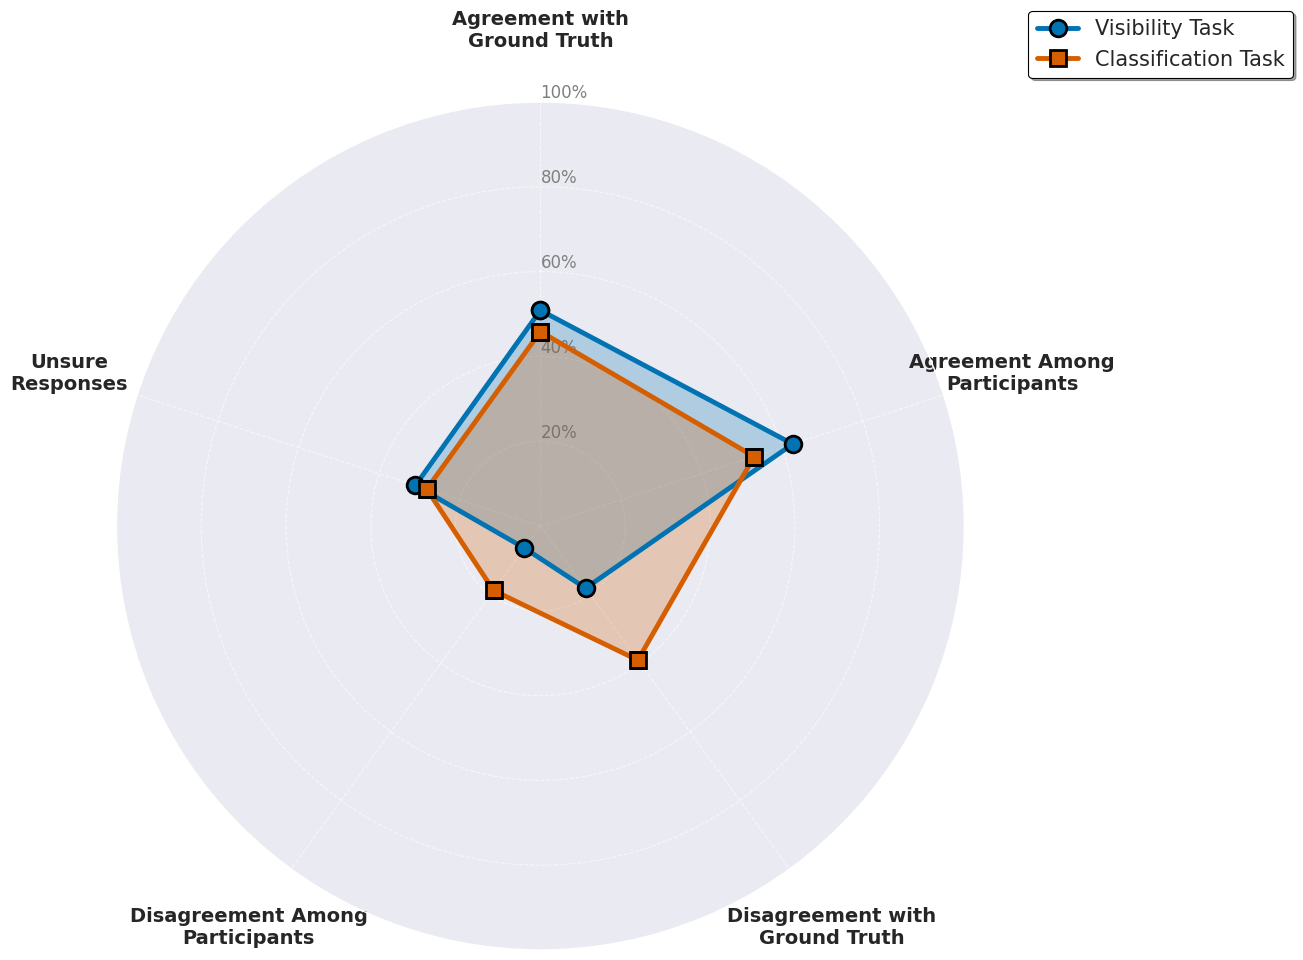


EXPERT RESPONSE PATTERNS SUMMARY
Metric                                             Visibility      Classification 
--------------------------------------------------------------------------------
Agreement with Ground Truth (%)                            50.9           45.9
Agreement Among Participants (%)                           62.6           53.0
Disagreement with Ground Truth (%)                         18.1           39.1
Disagreement Among Participants (%)                         6.4           18.8
Unsure Responses (%)                                       31.0           28.2
--------------------------------------------------------------------------------
TOTAL (should sum to ~100%)                               100.0          113.2


In [41]:
import matplotlib.pyplot as plt
import numpy as np
from math import pi
import seaborn as sns

# ============================================================================
# EXTRACT METRICS FROM YOUR COMPREHENSIVE DATAFRAME
# ============================================================================

# Agreement metrics (already in comprehensive_df)
vis_agreement_gt = comprehensive_df['Agreement_vs_GroundTruth_Vis_%'].mean()
class_agreement_gt = comprehensive_df['Agreement_vs_GroundTruth_Class_%'].mean()

vis_agreement_participants = comprehensive_df['Agreement_Across_Participants_Vis_%'].mean()
class_agreement_participants = comprehensive_df['Agreement_Across_Participants_Class_%'].mean()

# Disagreement metrics (already in comprehensive_df)
vis_disagreement = comprehensive_df['Disagreement_Vis_%'].mean()
class_disagreement = comprehensive_df['Disagreement_Class_%'].mean()

# For disagreement among participants, calculate: 100 - agreement_across - unsure
vis_unsure = comprehensive_df['Unsure_Vis_%'].mean()
class_unsure = comprehensive_df['Unsure_Class_%'].mean()

vis_disagreement_participants = 100 - vis_agreement_participants - vis_unsure
class_disagreement_participants = 100 - class_agreement_participants - class_unsure

# ============================================================================
# BUILD RADAR METRICS (ALL ON 0-100 SCALE)
# ============================================================================

vis_values = [
    vis_agreement_gt,                    # Agreement with ground truth
    vis_agreement_participants,          # Agreement among participants
    vis_disagreement,                    # Disagreement with ground truth
    vis_disagreement_participants,       # Disagreement among participants
    vis_unsure                           # Unsure responses
]

class_values = [
    class_agreement_gt,
    class_agreement_participants,
    class_disagreement,
    class_disagreement_participants,
    class_unsure
]

# ============================================================================
# CREATE RADAR PLOT WITH COLORBLIND PALETTE
# ============================================================================
categories = [
    'Agreement with\nGround Truth',
    'Agreement Among\nParticipants',
    'Disagreement with\nGround Truth',
    'Disagreement Among\nParticipants',
    'Unsure\nResponses'
]

N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
vis_values += vis_values[:1]
class_values += class_values[:1]
angles += angles[:1]

# Plot setup
fig, ax = plt.subplots(figsize=(14, 14), subplot_kw=dict(projection='polar'))
sns.set_style('darkgrid')

# Use explicit colorblind-friendly colors
colorblind_palette = sns.color_palette('colorblind')
vis_color = colorblind_palette[0]  # Blue
class_color = colorblind_palette[3]  # Red

ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)

# Move axis labels outside by adjusting pad
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=14, fontweight='bold',
                   verticalalignment='center')

# Increase the distance of labels from the plot
ax.tick_params(axis='x', pad=40)  # Increase padding to move labels outward

# Y-axis
ax.set_rlabel_position(0)
plt.yticks([20, 40, 60, 80, 100], ["20%", "40%", "60%", "80%", "100%"],
           color="grey", size=12)
plt.ylim(0, 100)

# Plot data - Visibility Task
ax.plot(angles, vis_values, linewidth=3.5, linestyle='solid',
        label='Visibility Task', color=vis_color, marker='o', markersize=12,
        markeredgecolor='black', markeredgewidth=2)
ax.fill(angles, vis_values, alpha=0.25, color=vis_color)

# Plot data - Classification Task
ax.plot(angles, class_values, linewidth=3.5, linestyle='solid',
        label='Classification Task', color=class_color, marker='s', markersize=12,
        markeredgecolor='black', markeredgewidth=2)
ax.fill(angles, class_values, alpha=0.25, color=class_color)

# Styling
ax.grid(True, linestyle='--', linewidth=0.8, alpha=0.6)

# Legend
plt.legend(loc='upper right', bbox_to_anchor=(1.4, 1.12),
           fontsize=15, frameon=True, shadow=True,
           facecolor='white', edgecolor='black', framealpha=1)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'radar_response_patterns.tif'),
            dpi=400, bbox_inches='tight')
plt.show()

# ============================================================================
# PRINT DETAILED SUMMARY
# ============================================================================
print("\n" + "="*80)
print("EXPERT RESPONSE PATTERNS SUMMARY")
print("="*80)
print(f"{'Metric':<50} {'Visibility':<15} {'Classification':<15}")
print("-"*80)
print(f"{'Agreement with Ground Truth (%)':<50} {vis_agreement_gt:>12.1f}   {class_agreement_gt:>12.1f}")
print(f"{'Agreement Among Participants (%)':<50} {vis_agreement_participants:>12.1f}   {class_agreement_participants:>12.1f}")
print(f"{'Disagreement with Ground Truth (%)':<50} {vis_disagreement:>12.1f}   {class_disagreement:>12.1f}")
print(f"{'Disagreement Among Participants (%)':<50} {vis_disagreement_participants:>12.1f}   {class_disagreement_participants:>12.1f}")
print(f"{'Unsure Responses (%)':<50} {vis_unsure:>12.1f}   {class_unsure:>12.1f}")
print("-"*80)
print(f"{'TOTAL (should sum to ~100%)':<50} {vis_agreement_gt+vis_disagreement+vis_unsure:>12.1f}   {class_agreement_gt+class_disagreement+class_unsure:>12.1f}")
print("="*80)

Relates experts’ uncertainty (unsure response rate) to their performance
(agreement with reference labels), stratified by frost experience level, and
visualizes this for both tasks.

This script:
1. Loads the per-participant metrics (including unsure rates and agreement with
   ground truth) and manually maps each participant ID to a frost experience
   category (“Little to no experience”, “Some experience”, “Significant
   experience”), adding this as a new column.
2. For the visibility task and classification task separately, computes the
   Spearman correlation between uncertainty (% unsure responses) and
   performance (% agreement with reference labels), then creates colorblind-
   friendly scatter plots where points are colored by experience level and a
   fitted linear trend line is overlaid; correlation coefficients and p-values
   are shown in inset text boxes.
3. Combines both scatter plots into a two-panel figure with a shared legend
   summarizing the experience groups, saves the figure as a high-resolution
   .tif (and a duplicate export for publication use), and prints the numerical
   correlation statistics along with a simple “significant / not significant”
   interpretation for each task.
4. Optionally generates a single, standalone scatter plot for the classification
   task only (intended for Figure 7), again with experience-based coloring and
   a trend line, exports it as .tif and .pdf, and prints interpretive notes
   describing how different quadrants (e.g. “cautious but accurate” vs
   “overconfident and struggling”) reflect distinct expert response strategies.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_870/2765895429.py:92: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.

/tmp/ipykernel_870/2765895429.py:136: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.




Figure saved to: /content/drive/My Drive/uncertainty_vs_performance_scatter.tif
PDF version saved to: /content/drive/My Drive/uncertainty_vs_performance_scatter.tif


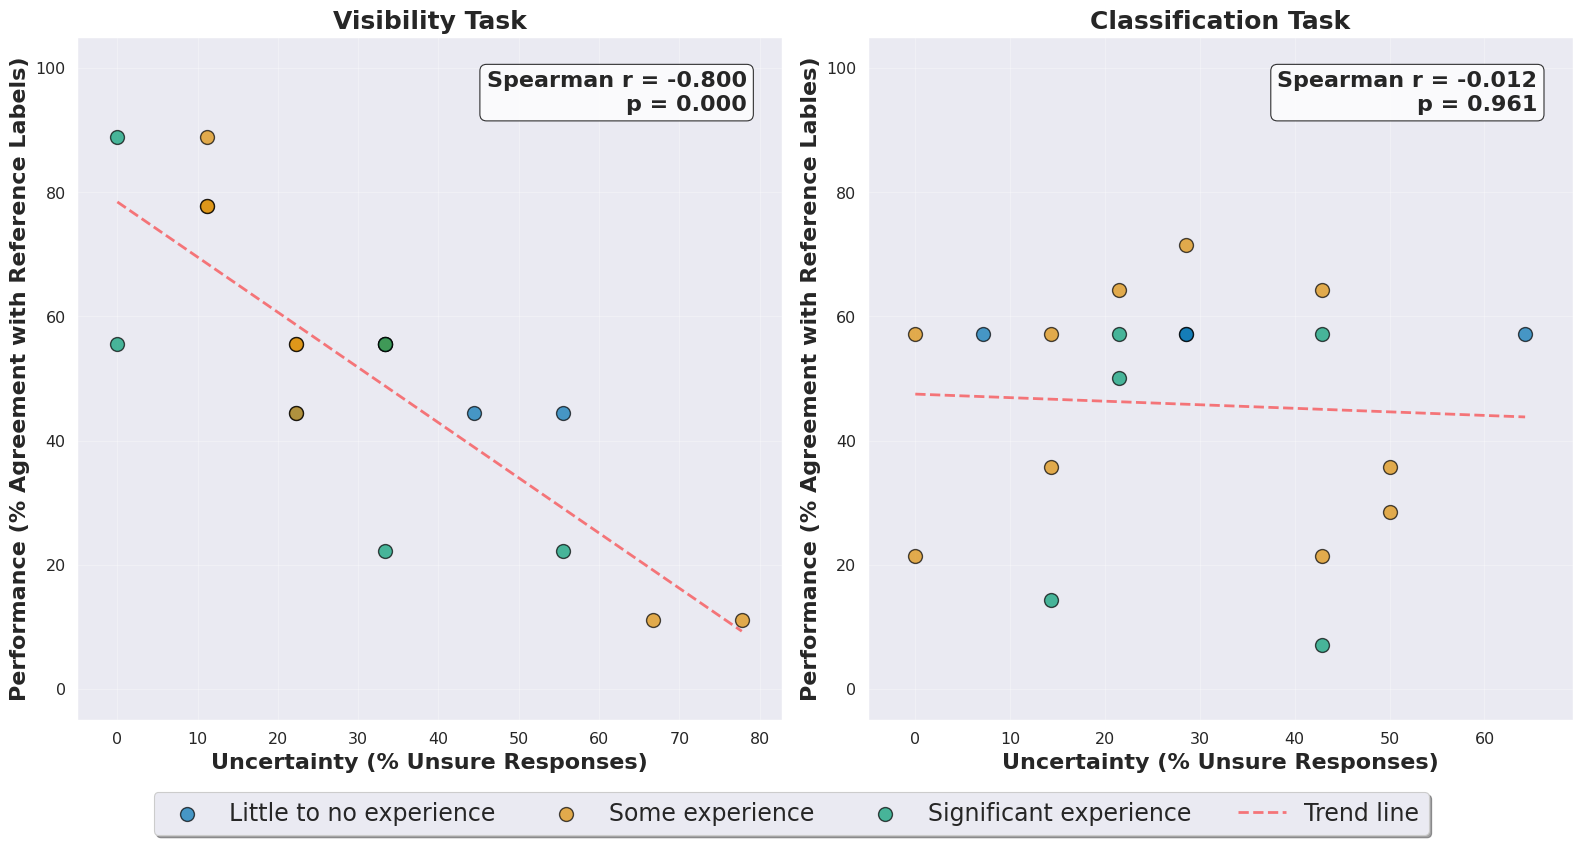


CORRELATION STATISTICS
Visibility Task:
  Spearman r = -0.8000
  p-value = 0.0000
  Interpretation: Significant correlation

Classification Task:
  Spearman r = -0.0120
  p-value = 0.9611
  Interpretation: Not significant correlation


/tmp/ipykernel_870/2765895429.py:220: UserWarning:

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.




Single plot (classification only) saved to: /content/drive/My Drive/uncertainty_vs_performance_classification_only.tif
PDF version saved to: /content/drive/My Drive/uncertainty_vs_performance_classification_only.pdf


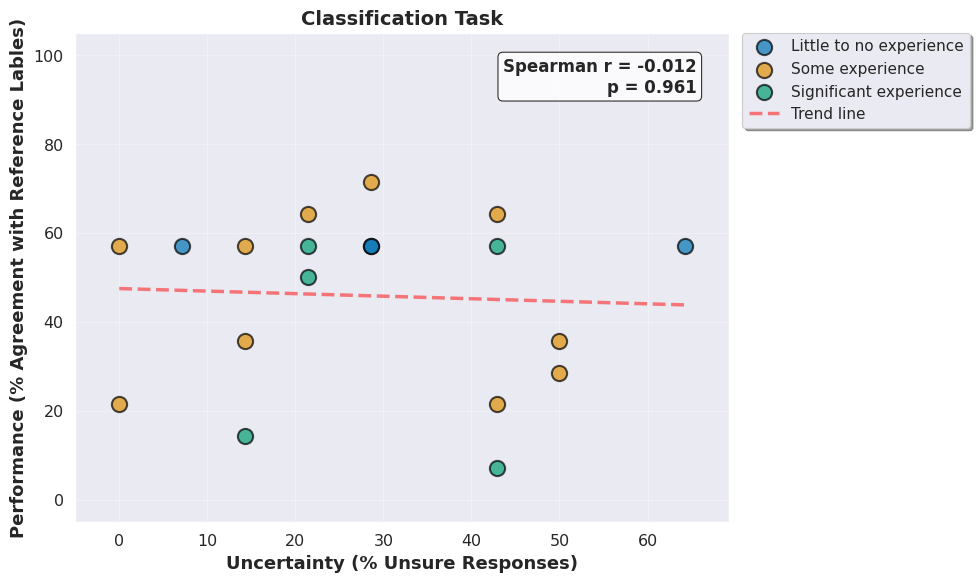


NOTES FOR FIGURE 7d
The scatter plot shows individual expert strategies:
- Top-right quadrant: Cautious but accurate (high uncertainty, high performance)
- Top-left quadrant: Confident and accurate (low uncertainty, high performance)
- Bottom-right quadrant: Struggling + uncertain
- Bottom-left quadrant: Struggling + overconfident

The flat regression line visualizes the non-significant correlation,
demonstrating that uncertainty does not predict performance.


In [43]:
import numpy as np
import pandas as pd
from google.colab import drive
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import spearmanr

# Mount Google Drive
drive.mount('/content/drive')

# Load the comprehensive metrics file
file_path = '/content/drive/My Drive/comprehensive_participant_metrics.xlsx'
df = pd.read_excel(file_path)

# Load the original voting poll to get experience levels
voting_file = '/content/drive/My Drive/voting_poll.xlsx'
voting_df = pd.read_excel(voting_file, sheet_name='results')

# Extract experience information (assuming there's a column for frost experience)
# Adjust column name based on your actual data
# This assumes you have columns like 'frost_experience' or similar
# If you need to manually add experience levels, you can create a dictionary

# Example: Create experience mapping (adjust based on your actual data)
# If you have experience in the voting_poll file, extract it:
# experience_mapping = voting_df.set_index('ID')['frost_experience'].to_dict()

# OR manually define based on your knowledge:
experience_mapping = {
    # Little/no experience (4 participants)
    1: 'Little to no experience',
    2: 'Little to no experience',
    3: 'Little to no experience',
    4: 'Little to no experience',

    # Some experience (10 participants)
    5: 'Some experience',
    6: 'Some experience',
    7: 'Some experience',
    8: 'Some experience',
    9: 'Some experience',
    10: 'Some experience',
    11: 'Some experience',
    12: 'Some experience',
    13: 'Some experience',
    14: 'Some experience',

    # Significant experience (5 participants)
    15: 'Significant experience',
    16: 'Significant experience',
    17: 'Significant experience',
    18: 'Significant experience',
    19: 'Significant experience'
}

# Add experience level to dataframe
df['Experience_Level'] = df['Participant_ID'].map(experience_mapping)

# Output directory
output_dir = "/content/drive/My Drive"
os.makedirs(output_dir, exist_ok=True)

# Set style
sns.set_style("darkgrid")
sns.set_context("paper", font_scale=1.3)
sns.set_palette("colorblind")

# Create figure with two subplots (visibility and classification)
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Define colors using colorblind-friendly palette
colorblind_colors = sns.color_palette("colorblind", 10)
color_map = {
    'Little to no experience': colorblind_colors[0],  # Blue
    'Some experience': colorblind_colors[1],          # Orange
    'Significant experience': colorblind_colors[2]    # Green
}

# Define experience order for consistent legend
experience_order = ['Little to no experience', 'Some experience', 'Significant experience']

# ========== PANEL 1: VISIBILITY TASK ==========
ax1 = axes[0]

# Calculate Spearman correlation
r_vis, p_vis = spearmanr(df['Unsure_Vis_%'], df['Agreement_vs_GroundTruth_Vis_%'])

# Create scatter plot
for exp_level in experience_order:
    mask = df['Experience_Level'] == exp_level
    ax1.scatter(
        df.loc[mask, 'Unsure_Vis_%'],
        df.loc[mask, 'Agreement_vs_GroundTruth_Vis_%'],
        c=color_map[exp_level],
        label=exp_level,
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidths=1
    )

# Add regression line (flat if no correlation)
z = np.polyfit(df['Unsure_Vis_%'], df['Agreement_vs_GroundTruth_Vis_%'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Unsure_Vis_%'].min(), df['Unsure_Vis_%'].max(), 100)
ax1.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Trend line')

# Labels and title
ax1.set_xlabel('Uncertainty (% Unsure Responses)', fontsize=16, fontweight='bold')
ax1.set_ylabel('Performance (% Agreement with Reference Labels)', fontsize=16, fontweight='bold')
ax1.set_title('Visibility Task', fontsize=18, fontweight='bold')

# Add Spearman correlation as text box in plot - UPPER RIGHT
textstr = f'Spearman r = {r_vis:.3f}\np = {p_vis:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=16,
         verticalalignment='top', horizontalalignment='right', fontweight='bold', bbox=props)

# Add grid
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-5, df['Unsure_Vis_%'].max() + 5)
ax1.set_ylim(-5, 105)

# NO legend here - will add single legend later

# ========== PANEL 2: CLASSIFICATION TASK ==========
ax2 = axes[1]

# Calculate Spearman correlation
r_class, p_class = spearmanr(df['Unsure_Class_%'], df['Agreement_vs_GroundTruth_Class_%'])

# Create scatter plot
for exp_level in experience_order:
    mask = df['Experience_Level'] == exp_level
    ax2.scatter(
        df.loc[mask, 'Unsure_Class_%'],
        df.loc[mask, 'Agreement_vs_GroundTruth_Class_%'],
        c=color_map[exp_level],
        label=exp_level,
        s=100,
        alpha=0.7,
        edgecolors='black',
        linewidths=1
    )

# Add regression line
z = np.polyfit(df['Unsure_Class_%'], df['Agreement_vs_GroundTruth_Class_%'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Unsure_Class_%'].min(), df['Unsure_Class_%'].max(), 100)
ax2.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2, label='Trend line')

# Labels and title
ax2.set_xlabel('Uncertainty (% Unsure Responses)', fontsize=16, fontweight='bold')
ax2.set_ylabel('Performance (% Agreement with Reference Lables)', fontsize=16, fontweight='bold')
ax2.set_title('Classification Task', fontsize=18, fontweight='bold')

# Add Spearman correlation as text box in plot - UPPER RIGHT
textstr = f'Spearman r = {r_class:.3f}\np = {p_class:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
ax2.text(0.95, 0.95, textstr, transform=ax2.transAxes, fontsize=16,
         verticalalignment='top', horizontalalignment='right', fontweight='bold', bbox=props)

# Add grid
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-5, df['Unsure_Class_%'].max() + 5)
ax2.set_ylim(-5, 105)

# NO legend here - will add single legend later

# ========== ADD SINGLE LEGEND FOR BOTH PLOTS ==========
# Collect handles and labels from first plot (they're the same for both)
handles, labels = ax1.get_legend_handles_labels()

# Create single legend at the bottom center below plots
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.07),
           ncol=4, frameon=True, fancybox=True, shadow=True, fontsize=17)

# Overall title
#fig.suptitle('Relationship Between Uncertainty and Performance',
#             fontsize=15, fontweight='bold', y=1.00)

# Adjust layout
plt.tight_layout()

# Save figure
output_path = os.path.join(output_dir, 'uncertainty_vs_performance_scatter.tif')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {output_path}")

# Also save as PDF for publication quality
output_path_pdf = os.path.join(output_dir, 'uncertainty_vs_performance_scatter.tif')
plt.savefig(output_path_pdf, dpi=300, bbox_inches='tight')
print(f"PDF version saved to: {output_path_pdf}")

plt.show()

# Print correlation statistics
print("\n" + "="*80)
print("CORRELATION STATISTICS")
print("="*80)
print(f"Visibility Task:")
print(f"  Spearman r = {r_vis:.4f}")
print(f"  p-value = {p_vis:.4f}")
print(f"  Interpretation: {'Significant' if p_vis < 0.05 else 'Not significant'} correlation")
print()
print(f"Classification Task:")
print(f"  Spearman r = {r_class:.4f}")
print(f"  p-value = {p_class:.4f}")
print(f"  Interpretation: {'Significant' if p_class < 0.05 else 'Not significant'} correlation")

# ========== OPTIONAL: SINGLE PLOT VERSION (Classification only) ==========
# If you prefer just one plot for the classification task to add to Figure 7

fig_single, ax_single = plt.subplots(figsize=(10, 6))

# Create scatter plot
for exp_level in experience_order:
    mask = df['Experience_Level'] == exp_level
    ax_single.scatter(
        df.loc[mask, 'Unsure_Class_%'],
        df.loc[mask, 'Agreement_vs_GroundTruth_Class_%'],
        c=color_map[exp_level],
        label=exp_level,
        s=120,
        alpha=0.7,
        edgecolors='black',
        linewidths=1.5
    )

# Add regression line
z = np.polyfit(df['Unsure_Class_%'], df['Agreement_vs_GroundTruth_Class_%'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['Unsure_Class_%'].min(), df['Unsure_Class_%'].max(), 100)
ax_single.plot(x_line, p(x_line), "r--", alpha=0.5, linewidth=2.5, label='Trend line')

# Labels
ax_single.set_xlabel('Uncertainty (% Unsure Responses)', fontsize=13, fontweight='bold')
ax_single.set_ylabel('Performance (% Agreement with Reference Lables)', fontsize=13, fontweight='bold')
ax_single.set_title('Classification Task', fontsize=14, fontweight='bold')

# Add Spearman correlation as text box in plot - UPPER RIGHT
textstr = f'Spearman r = {r_class:.3f}\np = {p_class:.3f}'
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='black')
ax_single.text(0.95, 0.95, textstr, transform=ax_single.transAxes, fontsize=12,
               verticalalignment='top', horizontalalignment='right', bbox=props, fontweight='bold')

# Grid and limits
ax_single.grid(True, alpha=0.3)
ax_single.set_xlim(-5, df['Unsure_Class_%'].max() + 5)
ax_single.set_ylim(-5, 105)

# Legend outside plot
ax_single.legend(loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True,
                 fancybox=True, shadow=True, fontsize=11, borderaxespad=0)

plt.tight_layout()

# Save single plot version
output_path_single = os.path.join(output_dir, 'uncertainty_vs_performance_classification_only.tif')
plt.savefig(output_path_single, dpi=300, bbox_inches='tight')
print(f"\nSingle plot (classification only) saved to: {output_path_single}")

output_path_single_pdf = os.path.join(output_dir, 'uncertainty_vs_performance_classification_only.pdf')
plt.savefig(output_path_single_pdf, dpi=300, bbox_inches='tight')
print(f"PDF version saved to: {output_path_single_pdf}")

plt.show()

print("\n" + "="*80)
print("NOTES FOR FIGURE 7d")
print("="*80)
print("The scatter plot shows individual expert strategies:")
print("- Top-right quadrant: Cautious but accurate (high uncertainty, high performance)")
print("- Top-left quadrant: Confident and accurate (low uncertainty, high performance)")
print("- Bottom-right quadrant: Struggling + uncertain")
print("- Bottom-left quadrant: Struggling + overconfident")
print("\nThe flat regression line visualizes the non-significant correlation,")
print("demonstrating that uncertainty does not predict performance.")

Quantifies how each rater’s accuracy on the frost classification task varies
with their self-reported frost experience, and visualizes this relationship.

This cell:
1. Loads the voting spreadsheet, separates expert raters from the ground-truth
   row (ID=20), and identifies visibility (`vis_img*`) and classification
   (`class_img*`) columns. For each rater, it computes percent agreement with
   the ground-truth labels for both the detection (visibility) and
   classification tasks, while also retaining their frost-experience category,
   broader expertise level, and years in the field.
2. Builds a per-rater summary DataFrame containing these metadata and task
   accuracies, then filters to raters with valid frost-experience categories
   (“Little to no experience”, “Some experience”, “Significant experience”).
3. Focuses on the classification task and creates a colorblind-friendly
   boxplot + stripplot showing how agreement with ground truth (%) varies
   across the three frost-experience groups, saving the figure at
   publication-ready resolution.
4. Prints summary statistics (N, mean, median, standard deviation, min, max)
   of classification accuracy for each experience level, providing a concise
   quantitative view of how frost experience relates to classification
   performance.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Agreement per Rater ===
    Rater_ID         Frost_Experience        Expertise_Level  Years_in_Field  \
0          1   Significant experience           Intermediate              12   
1          2  Little to no experience  Beginner/Early Career               4   
2          3          Some experience  Beginner/Early Career               2   
3          4          Some experience           Intermediate              12   
4          5          Some experience           Intermediate              10   
5          6          Some experience           Intermediate               5   
6          7   Significant experience        Advanced/Expert              34   
7          8   Significant experience        Advanced/Expert              30   
8          9   Significant experience        Advanced/Expert              50   
9         10          Some experience      

/tmp/ipykernel_870/3967937237.py:85: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_870/3967937237.py:109: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.




Figure saved to: /content/drive/My Drive/expert_agreement_classification_frost_experience.png


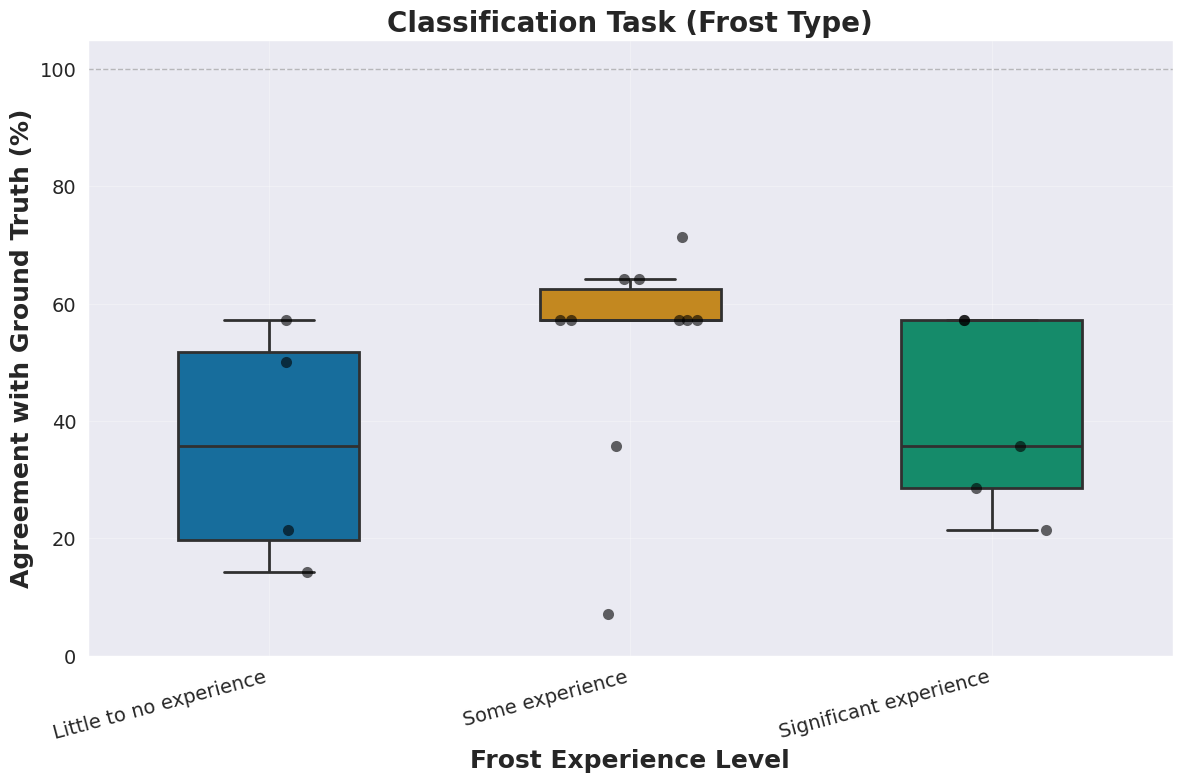


SUMMARY STATISTICS BY FROST EXPERIENCE LEVEL
Classification Task

Little to no experience:
  N = 4
  Mean = 35.71%
  Median = 35.71%
  Std = 21.03%
  Min = 14.29%
  Max = 57.14%

Some experience:
  N = 10
  Mean = 52.86%
  Median = 57.14%
  Std = 18.50%
  Min = 7.14%
  Max = 71.43%

Significant experience:
  N = 5
  Mean = 40.00%
  Median = 35.71%
  Std = 16.44%
  Min = 21.43%
  Max = 57.14%


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set seaborn style
sns.set_style('darkgrid')

# ----------------------------
# Load data
# ----------------------------
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# Calculate per-rater agreement
# ----------------------------
per_rater_results = []

for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # Get experience level info
    frost_experience = row.get("Experience with frost", "Unknown")
    expertise_level = row.get("Level of expertise", "Unknown")
    years_in_field = row.get("Years in field", np.nan)

    # --- VIS_IMG (Detection task) ---
    vis_true = df_gt[vis_cols].to_numpy().astype(int).flatten()
    vis_pred = row[vis_cols].to_numpy().astype(int).flatten()
    vis_vsGT = (vis_true == vis_pred).mean() * 100  # Convert to percentage

    # --- CLASS_IMG (Classification task) ---
    class_true = df_gt[class_cols].to_numpy().astype(int).flatten()
    class_pred = row[class_cols].to_numpy().astype(int).flatten()
    class_vsGT = (class_true == class_pred).mean() * 100  # Convert to percentage

    per_rater_results.append({
        "Rater_ID": rater_id,
        "Frost_Experience": frost_experience,
        "Expertise_Level": expertise_level,
        "Years_in_Field": years_in_field,
        "Agreement_Detection_%": vis_vsGT,
        "Agreement_Classification_%": class_vsGT
    })

per_rater_df = pd.DataFrame(per_rater_results)

print("=== Agreement per Rater ===")
print(per_rater_df)

# ----------------------------
# Define experience level order
# ----------------------------
frost_order = [
    'Little to no experience',
    'Some experience',
    'Significant experience'
]

# Filter to only include raters with valid frost experience
per_rater_df = per_rater_df[per_rater_df['Frost_Experience'].isin(frost_order)]

# ----------------------------
# Create boxplot + stripplot for Classification Task
# ----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Color palette - colorblind friendly
palette = sns.color_palette('colorblind', n_colors=3)

# Boxplot
sns.boxplot(data=per_rater_df,
            x='Frost_Experience',
            y='Agreement_Classification_%',
            order=frost_order,
            palette=palette,
            width=0.5,
            linewidth=2,
            ax=ax,
            showfliers=False)

# Stripplot (individual points)
sns.stripplot(data=per_rater_df,
              x='Frost_Experience',
              y='Agreement_Classification_%',
              order=frost_order,
              color='black',
              size=8,
              alpha=0.6,
              ax=ax,
              jitter=0.2)

ax.set_xlabel('Frost Experience Level', fontsize=18, fontweight='bold')
ax.set_ylabel('Agreement with Ground Truth (%)', fontsize=18, fontweight='bold')
ax.set_title('Classification Task (Frost Type)', fontsize=20, fontweight='bold')
ax.set_xticklabels(frost_order, rotation=15, ha='right', fontsize=14)
ax.tick_params(axis='y', labelsize=14)
ax.set_ylim(0, 105)
ax.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
output_path = '/content/drive/My Drive/expert_agreement_classification_frost_experience.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {output_path}")

plt.show()

# ----------------------------
# Print summary statistics
# ----------------------------
print("\n" + "="*60)
print("SUMMARY STATISTICS BY FROST EXPERIENCE LEVEL")
print("Classification Task")
print("="*60)

for exp_level in frost_order:
    data = per_rater_df[per_rater_df['Frost_Experience'] == exp_level]['Agreement_Classification_%']
    if len(data) > 0:
        print(f"\n{exp_level}:")
        print(f"  N = {len(data)}")
        print(f"  Mean = {data.mean():.2f}%")
        print(f"  Median = {data.median():.2f}%")
        print(f"  Std = {data.std():.2f}%")
        print(f"  Min = {data.min():.2f}%")
        print(f"  Max = {data.max():.2f}%")

Examines how frost experience relates to experts’ agreement with the reference
labels and with each other on the frost classification task.

This cell:
1. Loads the voting spreadsheet, separates expert raters from the ground-truth
   row (ID=20), and identifies visibility (`vis_img*`) and classification
   (`class_img*`) columns. For each rater, it computes:
   - Agreement with ground truth on the detection task,
   - Agreement with ground truth on the classification task,
   - Agreement with the across-rater majority vote on the classification task,
   while also keeping their frost-experience category, broader expertise level,
   and years in the field.
2. Builds a per-rater summary table and filters to raters with clearly defined
   frost-experience levels (“Little to no experience”, “Some experience”,
   “Significant experience”).
3. Produces two side-by-side, colorblind-friendly box+strip plots that show,
   across experience levels, (a) agreement with ground truth and (b) agreement
   with the group majority for the classification task, saving the resulting
   figure at publication-ready resolution.
4. Prints detailed summary statistics (N, mean, median, standard deviation,
   min, max) for both metrics within each frost-experience group, providing a
   compact quantitative view of how domain experience relates to both accuracy
   and consensus in classification.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Agreement per Rater ===
    Rater_ID         Frost_Experience        Expertise_Level  Years_in_Field  \
0          1   Significant experience           Intermediate              12   
1          2  Little to no experience  Beginner/Early Career               4   
2          3          Some experience  Beginner/Early Career               2   
3          4          Some experience           Intermediate              12   
4          5          Some experience           Intermediate              10   
5          6          Some experience           Intermediate               5   
6          7   Significant experience        Advanced/Expert              34   
7          8   Significant experience        Advanced/Expert              30   
8          9   Significant experience        Advanced/Expert              50   
9         10          Some experience      

/tmp/ipykernel_870/3671977843.py:95: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_870/3671977843.py:119: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

/tmp/ipykernel_870/3671977843.py:131: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_870/3671977843.py:155: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.




Figure saved to: /content/drive/My Drive/expert_agreement_classification_frost_experience.png


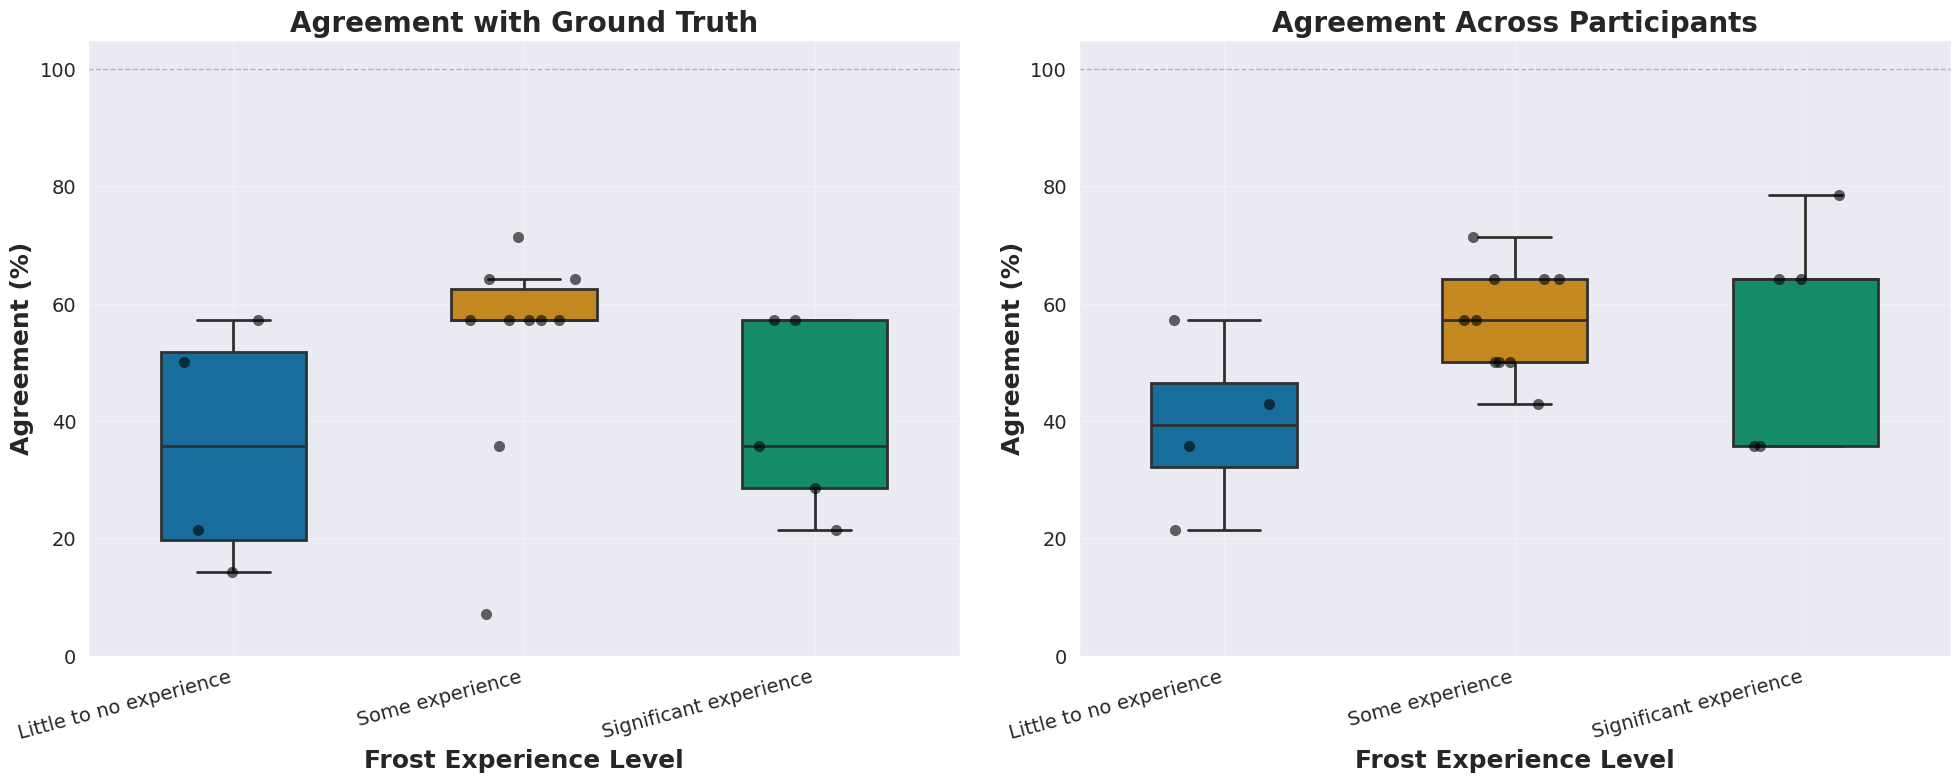


SUMMARY STATISTICS BY FROST EXPERIENCE LEVEL
Classification Task

Agreement with Ground Truth:
------------------------------------------------------------
  Little to no experience:
    N = 4
    Mean = 35.71%
    Median = 35.71%
    Std = 21.03%
    Min = 14.29%
    Max = 57.14%
  Some experience:
    N = 10
    Mean = 52.86%
    Median = 57.14%
    Std = 18.50%
    Min = 7.14%
    Max = 71.43%
  Significant experience:
    N = 5
    Mean = 40.00%
    Median = 35.71%
    Std = 16.44%
    Min = 21.43%
    Max = 57.14%

Agreement Across Participants:
------------------------------------------------------------
  Little to no experience:
    N = 4
    Mean = 39.29%
    Median = 39.29%
    Std = 14.87%
    Min = 21.43%
    Max = 57.14%
  Some experience:
    N = 10
    Mean = 57.14%
    Median = 57.14%
    Std = 8.91%
    Min = 42.86%
    Max = 71.43%
  Significant experience:
    N = 5
    Mean = 55.71%
    Median = 64.29%
    Std = 19.17%
    Min = 35.71%
    Max = 78.57%


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Set seaborn style
sns.set_style('darkgrid')

# ----------------------------
# Load data
# ----------------------------
file_path = '/content/drive/My Drive/voting_poll.xlsx'
df = pd.read_excel(file_path, sheet_name='results')

# Separate raters and ground truth
df_raters = df[df["ID"] != 20].reset_index(drop=True)
df_gt = df[df["ID"] == 20].reset_index(drop=True)

# Column groups
vis_cols = [c for c in df.columns if c.startswith("vis_img")]
class_cols = [c for c in df.columns if c.startswith("class_img")]

# ----------------------------
# Calculate per-rater agreement
# ----------------------------
per_rater_results = []

for idx, row in df_raters.iterrows():
    rater_id = row["ID"]

    # Get experience level info
    frost_experience = row.get("Experience with frost", "Unknown")
    expertise_level = row.get("Level of expertise", "Unknown")
    years_in_field = row.get("Years in field", np.nan)

    # --- VIS_IMG (Detection task) ---
    vis_true = df_gt[vis_cols].to_numpy().astype(int).flatten()
    vis_pred = row[vis_cols].to_numpy().astype(int).flatten()
    vis_vsGT = (vis_true == vis_pred).mean() * 100  # Convert to percentage

    # --- CLASS_IMG (Classification task) ---
    class_true = df_gt[class_cols].to_numpy().astype(int).flatten()
    class_pred = row[class_cols].to_numpy().astype(int).flatten()
    class_vsGT = (class_true == class_pred).mean() * 100  # Convert to percentage

    # Agreement across raters (majority vote)
    class_majority = df_raters[class_cols].mode().iloc[0].to_numpy().astype(int).flatten()
    class_vsMajority = (class_pred == class_majority).mean() * 100  # Convert to percentage

    per_rater_results.append({
        "Rater_ID": rater_id,
        "Frost_Experience": frost_experience,
        "Expertise_Level": expertise_level,
        "Years_in_Field": years_in_field,
        "Agreement_Detection_%": vis_vsGT,
        "Agreement_Classification_vsGT_%": class_vsGT,
        "Agreement_Classification_acrossRaters_%": class_vsMajority
    })

per_rater_df = pd.DataFrame(per_rater_results)

print("=== Agreement per Rater ===")
print(per_rater_df)

# ----------------------------
# Define experience level order
# ----------------------------
frost_order = [
    'Little to no experience',
    'Some experience',
    'Significant experience'
]

# Filter to only include raters with valid frost experience
per_rater_df = per_rater_df[per_rater_df['Frost_Experience'].isin(frost_order)]

# ----------------------------
# Create boxplot + stripplot for Classification Task
# ----------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Color palette - colorblind friendly
palette = sns.color_palette('colorblind', n_colors=3)

# ----------------------------
# Plot 1: Agreement with Ground Truth
# ----------------------------
ax1 = axes[0]

# Boxplot
sns.boxplot(data=per_rater_df,
            x='Frost_Experience',
            y='Agreement_Classification_vsGT_%',
            order=frost_order,
            palette=palette,
            width=0.5,
            linewidth=2,
            ax=ax1,
            showfliers=False)

# Stripplot (individual points)
sns.stripplot(data=per_rater_df,
              x='Frost_Experience',
              y='Agreement_Classification_vsGT_%',
              order=frost_order,
              color='black',
              size=8,
              alpha=0.6,
              ax=ax1,
              jitter=0.2)

ax1.set_xlabel('Frost Experience Level', fontsize=18, fontweight='bold')
ax1.set_ylabel('Agreement (%)', fontsize=18, fontweight='bold')
ax1.set_title('Agreement with Ground Truth', fontsize=20, fontweight='bold')
ax1.set_xticklabels(frost_order, rotation=15, ha='right', fontsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_ylim(0, 105)
ax1.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax1.grid(True, alpha=0.3)

# ----------------------------
# Plot 2: Agreement Across Participants
# ----------------------------
ax2 = axes[1]

# Boxplot
sns.boxplot(data=per_rater_df,
            x='Frost_Experience',
            y='Agreement_Classification_acrossRaters_%',
            order=frost_order,
            palette=palette,
            width=0.5,
            linewidth=2,
            ax=ax2,
            showfliers=False)

# Stripplot (individual points)
sns.stripplot(data=per_rater_df,
              x='Frost_Experience',
              y='Agreement_Classification_acrossRaters_%',
              order=frost_order,
              color='black',
              size=8,
              alpha=0.6,
              ax=ax2,
              jitter=0.2)

ax2.set_xlabel('Frost Experience Level', fontsize=18, fontweight='bold')
ax2.set_ylabel('Agreement (%)', fontsize=18, fontweight='bold')
ax2.set_title('Agreement Across Participants', fontsize=20, fontweight='bold')
ax2.set_xticklabels(frost_order, rotation=15, ha='right', fontsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylim(0, 105)
ax2.axhline(y=100, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()

# Save the figure
output_path = '/content/drive/My Drive/expert_agreement_classification_frost_experience.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"\nFigure saved to: {output_path}")

plt.show()

# ----------------------------
# Print summary statistics
# ----------------------------
print("\n" + "="*60)
print("SUMMARY STATISTICS BY FROST EXPERIENCE LEVEL")
print("Classification Task")
print("="*60)

for metric_name, metric_col in [('Agreement with Ground Truth', 'Agreement_Classification_vsGT_%'),
                                  ('Agreement Across Participants', 'Agreement_Classification_acrossRaters_%')]:
    print(f"\n{metric_name}:")
    print("-" * 60)
    for exp_level in frost_order:
        data = per_rater_df[per_rater_df['Frost_Experience'] == exp_level][metric_col]
        if len(data) > 0:
            print(f"  {exp_level}:")
            print(f"    N = {len(data)}")
            print(f"    Mean = {data.mean():.2f}%")
            print(f"    Median = {data.median():.2f}%")
            print(f"    Std = {data.std():.2f}%")
            print(f"    Min = {data.min():.2f}%")
            print(f"    Max = {data.max():.2f}%")

In [46]:
#!pip freeze > requirements.txt